# Using Machine Learning to Classify Land Cover Types

**Goal:** decide on a model to predict land cover classifications for forested ecoregions in Washington and Oregon

**Created By:** Kathryn Wheeler, Ph.D.

**Reference labels:** [GLanCE](https://www.nature.com/articles/s41597-023-02798-5) — a global time series
land cover training/validation dataset — filtered to its North America records and Level-1 classes
(Water, Ice/Snow, Developed, Barren/Sparse, Trees, Shrubs, Herbaceous). Each GLanCE record is a segment
of years over which a location's land cover class is constant, so it is exploded into one row per year
before modeling.

**Predictors:** Google/DeepMind's [AlphaEarth Satellite Embedding](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL)
dataset — a 64-dimensional learned embedding per 10 m pixel per year (2017 onward), pulled from Earth
Engine at each GLanCE point/year. Because this embedding is itself the output of a pretrained geospatial
foundation model, classification only requires a lightweight model on top of it.

**Approach:** several classifiers are trained on the embeddings and compared on a shared, spatially
grouped held-out test set (grouped by GLanCE segment so no location leaks between train and test):
- **Random Forest** and **XGBoost**, both plain and hyperparameter-tuned via grouped cross-validation
- **XGBoost (spatial)** — the same tuned XGBoost with per-band neighborhood mean/std features added, to
  give the tree model some spatial context
- **Shallow MLP** — a small neural network on the 64-dim embeddings, plain and with early stopping
- **CNN** — a small convolutional network on a k×k neighborhood of embeddings around each point (rather
  than a single pixel), plain and with early stopping

The notebook ends by comparing every model's accuracy, per-class F1, and training time, both overall and
restricted to the Washington/Oregon subset of the test set.

## Setup


In [1]:
%load_ext autoreload
%autoreload 2

# ── Load libraries and functions ────────────────────────────────────────────────────────────
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import shape
import os
import ee
import geemap
import time
import joblib

from Glance_Class_Definitions import class1_dict, class2_dict, class1_subset, class2_subset
from Embedding_Utils import get_embeddings, EMBEDDING_BANDS, get_patch_arrays, align_patch_arrays, neighborhood_stats
from Tree_Ensemble import split_data, fit_random_forest, fit_xgboost, tune_random_forest, tune_xgboost, rf_validation_curve, _LabelDecodingClassifier
from MLP import fit_mlp, _MLPClassifier
from CNN import fit_cnn, _CNNClassifier
from Constants import DATA_DIR, MODEL_DIR
from Evaluation import plot_feature_importances, evaluate_model, compare_models, plot_training_curve, plot_validation_curve, class_count_table
from Model_Runner import variant_paths, fit_or_load, load_all_models
from Geo_Utils import get_wa_or_states, assign_wa_or_state

# ── Initiate GEE Project ────────────────────────────────────────────────────────────────────
ee.Initialize(project='turnkey-lacing-391919')

# ── Define Variables ────────────────────────────────────────────────────────────────────────
start_year = 2017
download_embeddings = True #If True, sample any missing years' embeddings from GEE; if False, only load years already cached locally
refit_models = False # When set to True, this will cause the models to be refit. Available saved models will be loaded when False

## Data Preparation

Load GLanCE, filter to North America / 2017+, explode segments to one row per year, join AlphaEarth embeddings, make the grouped train/test split, and sample the k×k embedding patches and their derived neighborhood mean/std features (used by the CNN and the spatial-XGBoost variants).

In [2]:
# ── Read in Glance Data ─────────────────────────────────────────────────────────────────────

geojson_path = os.path.join('Data', 'bu_glance_training_dataV1.geojson')
#https://www.nature.com/articles/s41597-023-02798-5#Sec10
#https://source.coop/boston-university/bu-glance

# Large file (~1.1 GB / ~1.87M features) — pyogrio is the fast, memory-efficient reader.
glance = gpd.read_file(geojson_path, engine='pyogrio')


In [3]:
# ── Filter Glance Data ──────────────────────────────────────────────────────────────────────
glance_NA = glance.loc[glance['Continent_Code']==1,] # Filter to just North America

glance_NA_filtered = glance_NA.loc[glance_NA['End_Year']>=start_year,]
print(glance_NA_filtered['Glance_Class_ID_level1'].isna().sum()==0) #Make sure that there are No NAs present

glance_NA_filtered = glance_NA_filtered[['Lat','Lon','Glance_ID','Start_Year','End_Year','Glance_Class_ID_level1','Glance_Class_ID_level2','geometry']]

end_year = glance_NA_filtered['End_Year'].unique().max()

True


In [4]:
# ── Per Year Explosion ──────────────────────────────────────────────────────────────────────
# One row per year each segment is active, clipped to AlphaEarth's 2017+ range.
expanded_Glance = glance_NA_filtered.copy()

# ── Explode segments into per-year rows ─────────────────────────────────────────────────────
expanded_Glance['Year'] = expanded_Glance.apply(
    lambda r: list(range(max(int(r['Start_Year']), start_year), int(r['End_Year']) + 1)),
    axis=1
)

expanded_Glance = expanded_Glance.drop(columns=['Start_Year', 'End_Year'])

expanded_Glance = expanded_Glance.explode('Year', ignore_index=True)

# ── Split into Level-1 (all rows) and Level-2 (drop 'Unknown' = 0) tables ───────────────────
expanded_Glance_Class1 = expanded_Glance.drop(columns = ['Glance_Class_ID_level2'])

expanded_Glance_Class2 = expanded_Glance.loc[expanded_Glance['Glance_Class_ID_level2'] != 0,]
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns = ['Glance_Class_ID_level1'])

# ── QC checks ───────────────────────────────────────────────────────────────────────────────
print([0] not in expanded_Glance_Class2['Glance_Class_ID_level2'].unique())
print(expanded_Glance_Class1.shape[0] > expanded_Glance_Class2.shape[0])
print(expanded_Glance_Class1['Year'].min(), expanded_Glance_Class1['Year'].max())


True
True
2017 2021


In [5]:
# ── Read in Embeddings and Organize ─────────────────────────────────────────────────────────
embeddings_dir = os.path.join('Data', 'Embeddings')

# ── Drop embedding columns from a prior run so this cell is safe to re-run ──────────────────
expanded_Glance_Class1 = expanded_Glance_Class1.drop(columns=EMBEDDING_BANDS, errors='ignore')
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns=EMBEDDING_BANDS, errors='ignore')

# ── Sample/cache once against Class1 (the superset), then join into both ────────────────────
unique_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()
embeddings_df = get_embeddings(unique_year_points, cache_dir=embeddings_dir, download_embeddings=download_embeddings)
embeddings_df['Year'] = embeddings_df['Year'].astype(expanded_Glance_Class1['Year'].dtype)
expanded_Glance_Class1 = expanded_Glance_Class1.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')
expanded_Glance_Class2 = expanded_Glance_Class2.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')

# ── QC checks ───────────────────────────────────────────────────────────────────────────────
print(f'Class1 rows with embeddings: {expanded_Glance_Class1.shape[0]} / {unique_year_points.shape[0]}')
print(f'Class2 rows with embeddings: {expanded_Glance_Class2.shape[0]}')
print(f'{expanded_Glance_Class1[EMBEDDING_BANDS].isna().sum().sum()} missing embedding values')


Loading cached embeddings for 2017 from Data/Embeddings/embeddings_2017.csv
Loading cached embeddings for 2018 from Data/Embeddings/embeddings_2018.csv
Loading cached embeddings for 2019 from Data/Embeddings/embeddings_2019.csv
Loading cached embeddings for 2020 from Data/Embeddings/embeddings_2020.csv
Loading cached embeddings for 2021 from Data/Embeddings/embeddings_2021.csv
Class1 rows with embeddings: 64004 / 64004
Class2 rows with embeddings: 48092
0 missing embedding values


In [6]:
# ── Split data into training and test ───────────────────────────────────────────────────────
expanded_Glance_Class1_Clean = expanded_Glance_Class1.drop(columns = ["geometry","Year","Lat","Lon"])

x_train, x_test, y_train, y_test = split_data(expanded_Glance_Class1_Clean, "Glance_Class_ID_level1")
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

In [7]:
# ── Patch Embeddings (for CNN and spatial XGBoost) ──────────────────────────────────────────
# Raw k x k x 64 window per point (radius=2 -> 5x5). The aligned array X_patch_all is
# cached to Data/ and reloaded if present, so sampling + alignment isn't repeated. Used
# by the CNN variants and by the XGBoost (spatial) neighborhood features.
patch_dir = os.path.join('Data', 'Embeddings_Patch')
patch_radius = 2
patch_all_path = os.path.join('Data', f'X_patch_all_r{patch_radius}.npy')

# ── Load cache, or sample + align + save ────────────────────────────────────────────────────
if os.path.exists(patch_all_path):
    X_patch_all = np.load(patch_all_path)
    print(f'Loaded cached X_patch_all from {patch_all_path}: {X_patch_all.shape}')
if not os.path.exists(patch_all_path) or X_patch_all.shape[0] != len(expanded_Glance_Class1):
    patch_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()
    patch_arrays, patch_keys = get_patch_arrays(
        patch_year_points, cache_dir=patch_dir, radius=patch_radius,
        download_embeddings=download_embeddings)
    X_patch_all = align_patch_arrays(patch_arrays, patch_keys,
                                     expanded_Glance_Class1[['Glance_ID', 'Year']])
    np.save(patch_all_path, X_patch_all)
    print(f'Saved X_patch_all to {patch_all_path}: {X_patch_all.shape}')

# ── Apply the existing train/test split to the patches ──────────────────────────────────────
X_train_patch = X_patch_all[x_train.index.values]
X_test_patch = X_patch_all[x_test.index.values]
print(f'Patch windows: {X_patch_all.shape}  (n, k, k, channels)')
print(f'Train/test patches: {X_train_patch.shape} / {X_test_patch.shape}')
print(f'Missing (all-NaN) patches in train: {int(np.isnan(X_train_patch).all(axis=(1, 2, 3)).sum())}')

# ── Neighborhood mean/std features (for XGBoost spatial), derived from the cached patches ───
nbhd_path = os.path.join('Data', f'nbhd_features_r{patch_radius}.parquet')
if os.path.exists(nbhd_path):
    nbhd_features = pd.read_parquet(nbhd_path)
    print(f'Loaded cached nbhd_features from {nbhd_path}: {nbhd_features.shape}')
if not os.path.exists(nbhd_path) or len(nbhd_features) != len(expanded_Glance_Class1):
    nbhd_features = neighborhood_stats(X_patch_all)
    nbhd_features.to_parquet(nbhd_path)
    print(f'Saved nbhd_features to {nbhd_path}: {nbhd_features.shape}')
nbhd_features.index = expanded_Glance_Class1.index
x_train_nbhd = pd.concat([x_train, nbhd_features.loc[x_train.index]], axis=1)
x_test_nbhd = pd.concat([x_test, nbhd_features.loc[x_test.index]], axis=1)

Loaded cached X_patch_all from Data/X_patch_all_r2.npy: (64004, 5, 5, 64)
Patch windows: (64004, 5, 5, 64)  (n, k, k, channels)
Train/test patches: (47975, 5, 5, 64) / (16029, 5, 5, 64)
Missing (all-NaN) patches in train: 0
Loaded cached nbhd_features from Data/nbhd_features_r2.parquet: (64004, 128)


## Models

Each cell fits (or loads, when `refit_models=False`) one variant, evaluates it on the shared held-out test set, and saves diagnostics to `Model_Outputs/`.

In [8]:
# ── Level 1 model settings ──────────────────────────────────────────────────────────────────
# Suffixed per class level (_c1 / _c2): the Level-2 section below sets its own out_dir_c2 /
# class_map_c2, so the two sections never share mutable state and any cell stays re-runnable
# in any order. Do not collapse these back to a bare out_dir / class_map.
out_dir_c1 = MODEL_DIR
class_map_c1 = class1_dict
subset_c1 = class1_subset

### Random Forest

Baseline random forest on the 64 AlphaEarth embedding dimensions, with class-balanced weights and default hyperparameters. Establishes the accuracy bar the other models aim to beat.

Training time: 12.34 seconds
               precision    recall  f1-score   support

        Water      0.990     0.986     0.988       841
    Developed      0.970     0.958     0.964      1153
Barren/Sparse      0.916     0.887     0.901       882
        Trees      0.971     0.968     0.970      5054
       Shrubs      0.772     0.898     0.830      1576
   Herbaceous      0.969     0.940     0.954      6523

     accuracy                          0.946     16029
    macro avg      0.931     0.939     0.935     16029
 weighted avg      0.949     0.946     0.947     16029

Overall accuracy : 0.946
Balanced accuracy: 0.939
Macro F1         : 0.935
Cohen's kappa    : 0.924
MCC              : 0.925


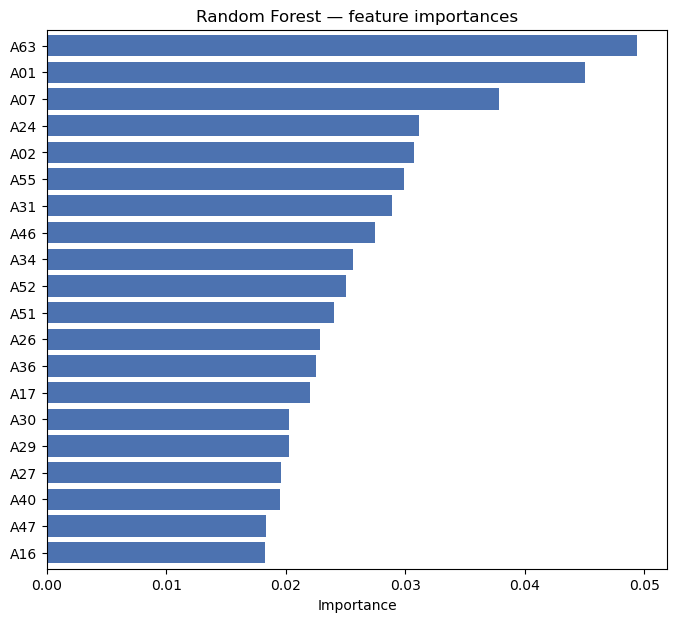

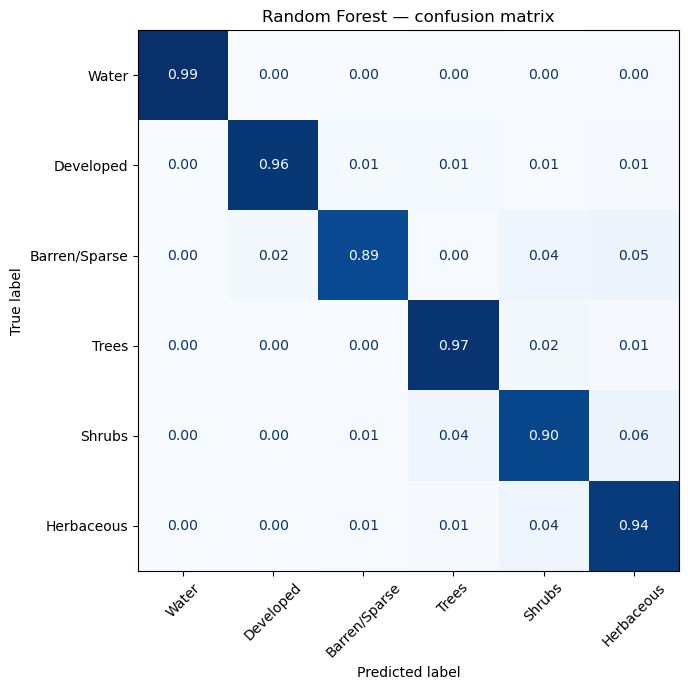

In [9]:
# ── Random Forest ───────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'random_forest')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'], lambda: fit_random_forest(x_train, y_train), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest — feature importances',
    save_path=paths['importances'])
rf_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='Random Forest — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (RF has no epochs -> validation curve instead) ───────────────────
if refit_models:
    vc_param, vc_train, vc_val = rf_validation_curve(
        x_train, y_train, groups_train, param_name='min_samples_leaf',
        param_range=(1, 2, 4, 8, 16))
    plot_validation_curve(
        vc_param, vc_train, vc_val, param_name='min_samples_leaf', scoring='macro F1',
        title='Random Forest — validation curve',
        save_path=paths['valcurve'])

### XGBoost

Gradient-boosted trees on the same 64 embeddings, with inverse-frequency sample weights for the class imbalance. A grouped validation split records the per-boosting-round loss curve.

Training time: 2.03 seconds
               precision    recall  f1-score   support

        Water      0.987     0.983     0.985       841
    Developed      0.977     0.955     0.966      1153
Barren/Sparse      0.917     0.895     0.906       882
        Trees      0.974     0.968     0.971      5054
       Shrubs      0.783     0.878     0.828      1576
   Herbaceous      0.965     0.948     0.957      6523

     accuracy                          0.947     16029
    macro avg      0.934     0.938     0.935     16029
 weighted avg      0.949     0.947     0.948     16029

Overall accuracy : 0.947
Balanced accuracy: 0.938
Macro F1         : 0.935
Cohen's kappa    : 0.926
MCC              : 0.926


<Axes: title={'center': 'XGBoost — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

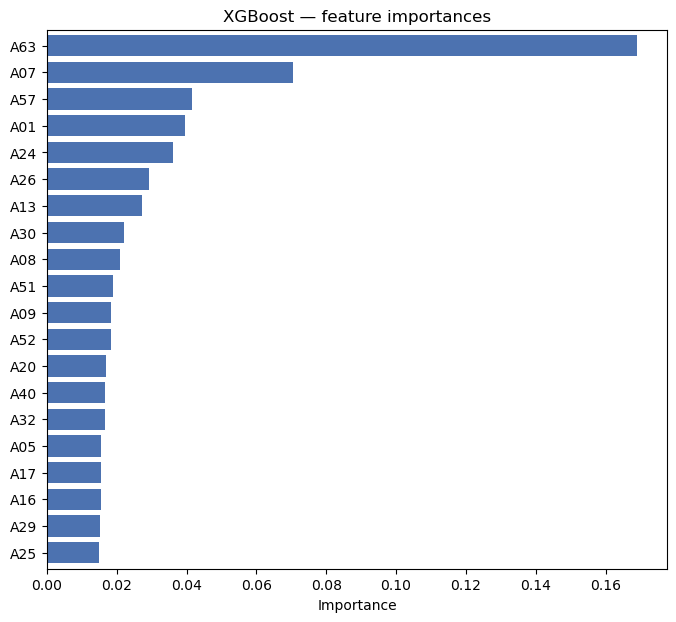

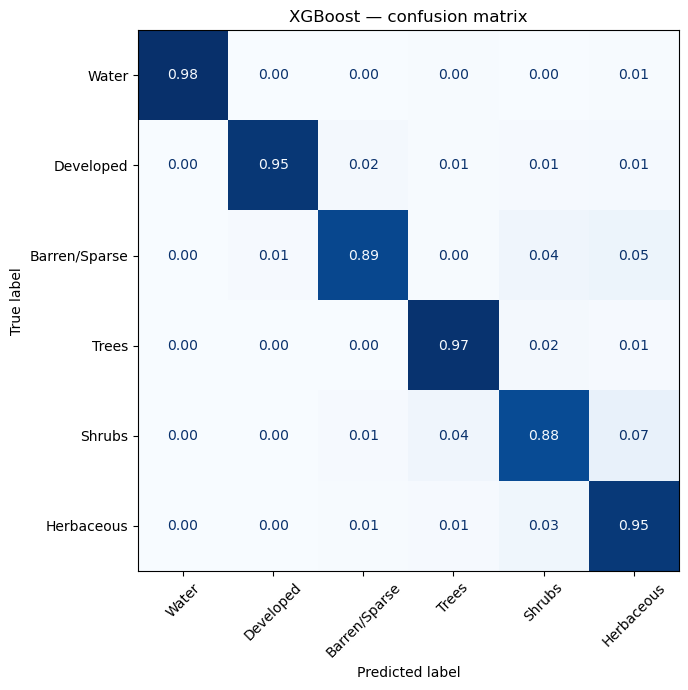

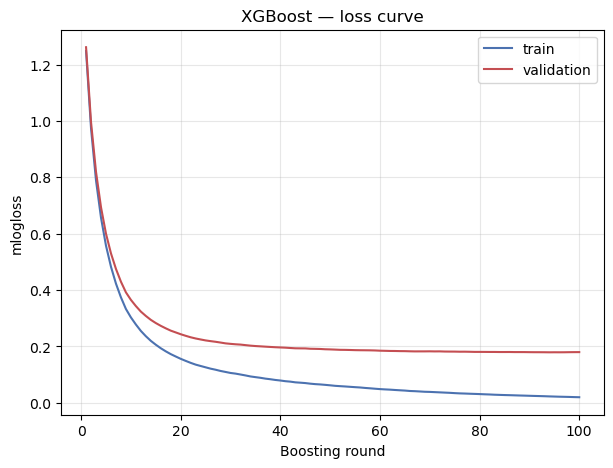

In [10]:
# ── XGBoost ─────────────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'XGBoost')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_xgboost(x_train, y_train, groups=groups_train), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='XGBoost — feature importances',
    save_path=paths['importances'])
xgb_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='XGBoost — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ───────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost — loss curve',
    save_path=paths['losscurve'])

### Random Forest (tuned)

The random forest with hyperparameters chosen by a grouped-CV randomized search (`max_depth`, `min_samples_leaf`, `max_features`, ...), selected on macro-F1 so the rare classes carry weight.

Search time: 717.81 seconds
               precision    recall  f1-score   support

        Water      0.988     0.985     0.986       841
    Developed      0.970     0.959     0.965      1153
Barren/Sparse      0.922     0.884     0.903       882
        Trees      0.972     0.968     0.970      5054
       Shrubs      0.771     0.893     0.828      1576
   Herbaceous      0.968     0.941     0.954      6523

     accuracy                          0.945     16029
    macro avg      0.932     0.939     0.934     16029
 weighted avg      0.948     0.945     0.946     16029

Overall accuracy : 0.945
Balanced accuracy: 0.939
Macro F1         : 0.934
Cohen's kappa    : 0.924
MCC              : 0.924


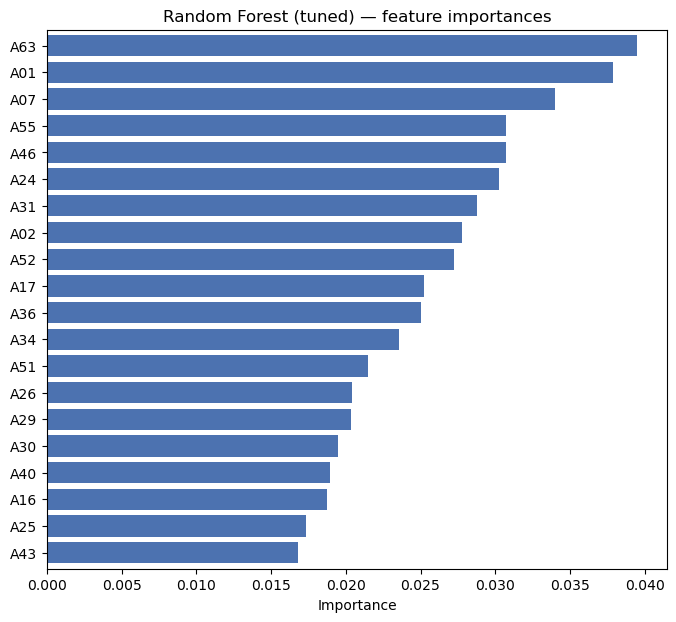

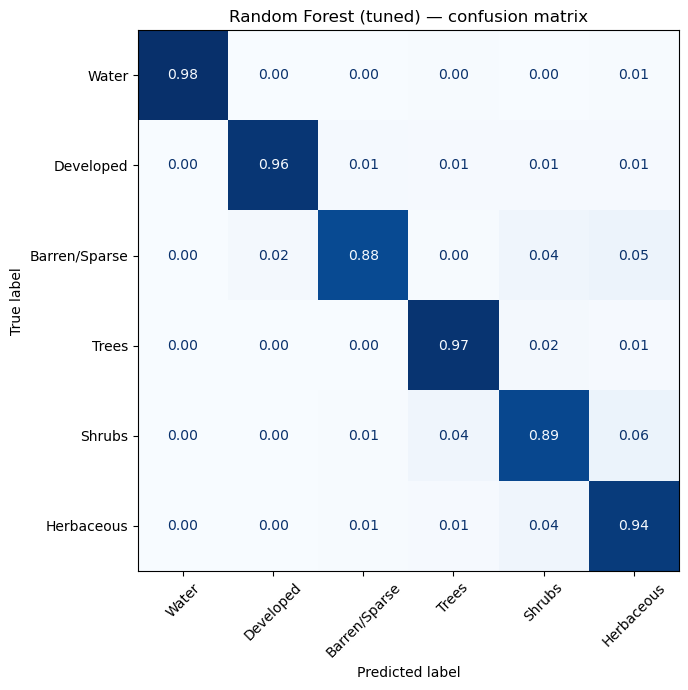

In [11]:
# ── Random Forest (grouped-CV tuned) ────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'random_forest_tuned', '_groupedCV')

def _fit_rf_tuned():
    mdl, training_time_sec, best_params = tune_random_forest(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_rf_tuned, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest (tuned) — feature importances',
    save_path=paths['importances'])
rf_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='Random Forest (tuned) — confusion matrix',
    save_path=paths['confusion'])

### XGBoost (tuned)

Grouped-CV randomized search over tree depth, learning rate, subsampling, and regularization (`gamma`, `reg_alpha`, `max_delta_step`). `n_estimators` is not tuned — the winning parameters are refit with early stopping, so the number of boosting rounds is chosen by validation loss.

Search time: 127.77 seconds
Early stopping chose best_iteration=437 (of up to 2000 rounds)
               precision    recall  f1-score   support

        Water      0.985     0.987     0.986       841
    Developed      0.979     0.965     0.972      1153
Barren/Sparse      0.910     0.897     0.903       882
        Trees      0.974     0.971     0.972      5054
       Shrubs      0.799     0.882     0.839      1576
   Herbaceous      0.968     0.950     0.959      6523

     accuracy                          0.950     16029
    macro avg      0.936     0.942     0.939     16029
 weighted avg      0.952     0.950     0.951     16029

Overall accuracy : 0.950
Balanced accuracy: 0.942
Macro F1         : 0.939
Cohen's kappa    : 0.930
MCC              : 0.930


<Axes: title={'center': 'XGBoost (tuned) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

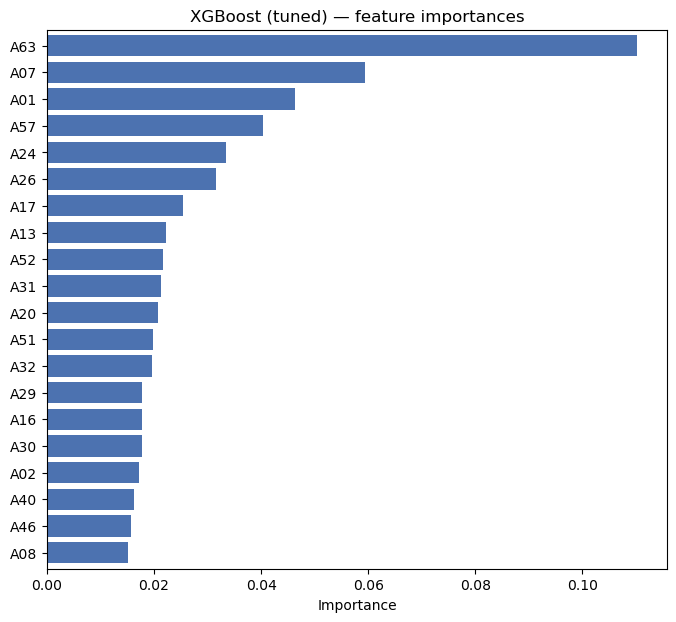

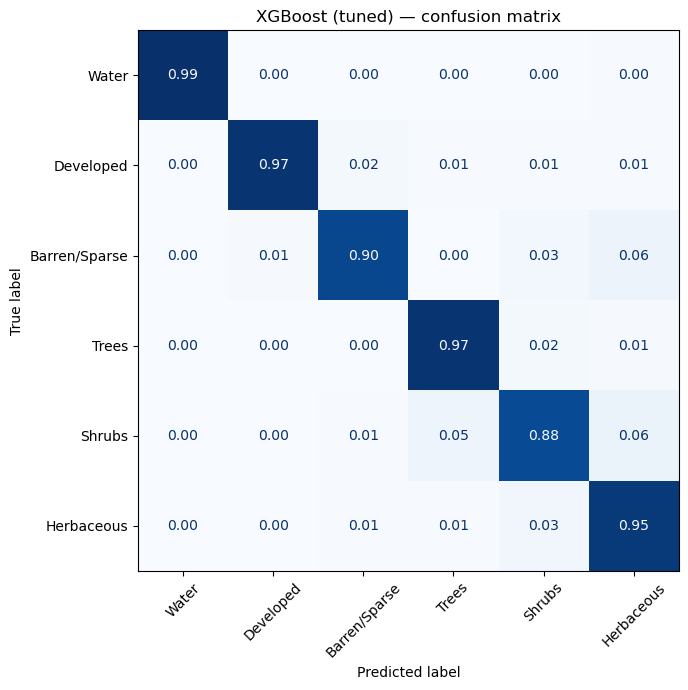

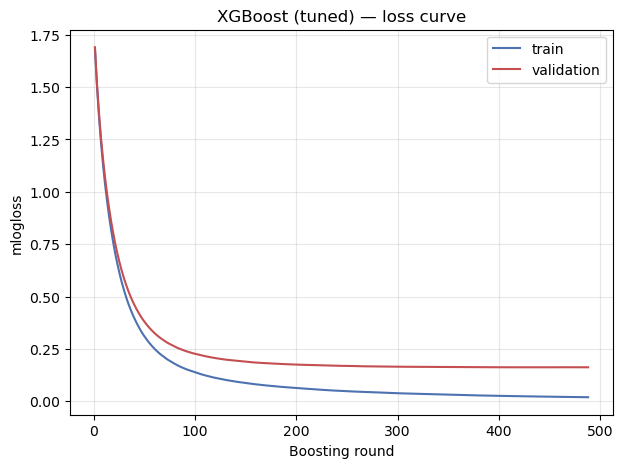

In [12]:
# ── XGBoost (grouped-CV tuned) ──────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'XGBoost_tuned', '_groupedCV')

def _fit_xgb_tuned():
    mdl, training_time_sec, best_params = tune_xgboost(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_xgb_tuned, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train, title='XGBoost (tuned) — feature importances',
    save_path=paths['importances'])
xgb_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='XGBoost (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss; early stopping trims rounds) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (tuned) — loss curve',
    save_path=paths['losscurve'])

### XGBoost (spatial)

The tuned XGBoost given spatial context: alongside each point's 64 center-pixel embeddings it also receives every band's neighborhood mean and standard deviation over the 5×5 window (192 features total). The statistics are derived from the cached patches when available, so no extra Earth Engine sampling is needed.

Search time: 525.56 seconds
Early stopping chose best_iteration=413 (of up to 2000 rounds)
               precision    recall  f1-score   support

        Water      0.986     0.985     0.985       841
    Developed      0.972     0.964     0.968      1153
Barren/Sparse      0.909     0.885     0.897       882
        Trees      0.973     0.969     0.971      5054
       Shrubs      0.790     0.866     0.827      1576
   Herbaceous      0.964     0.950     0.957      6523

     accuracy                          0.947     16029
    macro avg      0.932     0.936     0.934     16029
 weighted avg      0.948     0.947     0.947     16029

Overall accuracy : 0.947
Balanced accuracy: 0.936
Macro F1         : 0.934
Cohen's kappa    : 0.926
MCC              : 0.926


<Axes: title={'center': 'XGBoost (spatial) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

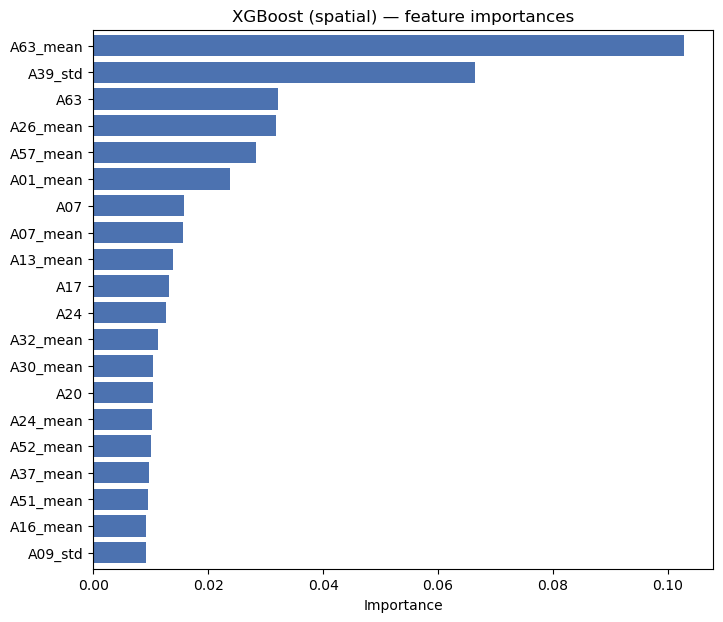

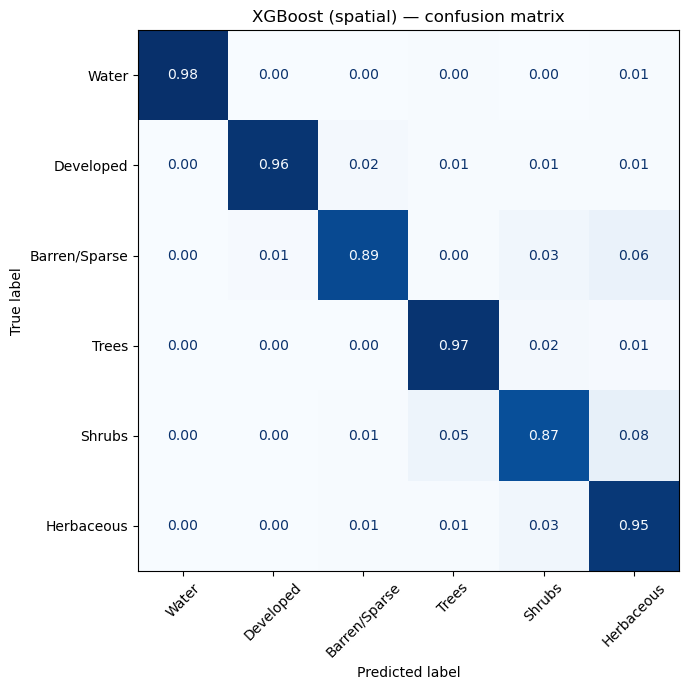

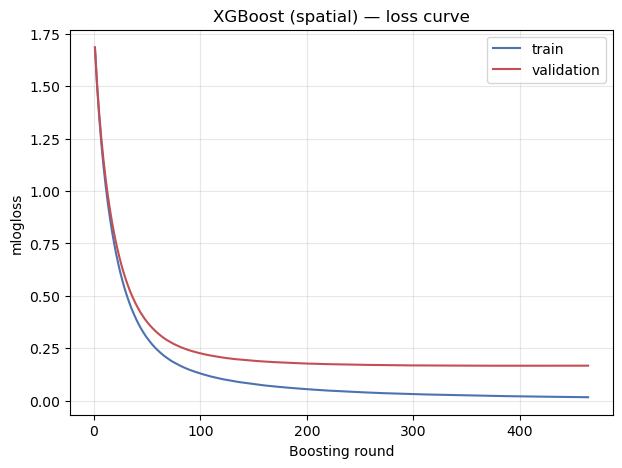

In [13]:
# ── XGBoost (spatial) ───────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'XGBoost_nbhd_tuned', '_spatial')

def _fit_xgb_spatial():
    mdl, training_time_sec, best_params = tune_xgboost(x_train_nbhd, y_train, groups_train)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_xgb_spatial, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train_nbhd, title='XGBoost (spatial) — feature importances',
    save_path=paths['importances'])
xgb_nbhd_tuned_metrics = evaluate_model(
    mdl, x_test_nbhd, y_test, class_map=class_map_c1,
    title='XGBoost (spatial) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ───────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (spatial) — loss curve',
    save_path=paths['losscurve'])

### Shallow MLP

A small neural network (64 → 128 → 64 → classes) trained on the embeddings for a fixed number of epochs with a class-weighted loss. Records a train/validation loss curve for the overfitting diagnostic.

Training time: 73.09 seconds
               precision    recall  f1-score   support

        Water      0.966     0.993     0.979       841
    Developed      0.964     0.970     0.967      1153
Barren/Sparse      0.847     0.908     0.876       882
        Trees      0.979     0.960     0.970      5054
       Shrubs      0.720     0.905     0.802      1576
   Herbaceous      0.978     0.917     0.946      6523

     accuracy                          0.937     16029
    macro avg      0.909     0.942     0.923     16029
 weighted avg      0.944     0.937     0.939     16029

Overall accuracy : 0.937
Balanced accuracy: 0.942
Macro F1         : 0.923
Cohen's kappa    : 0.913
MCC              : 0.914


<Axes: title={'center': 'Shallow MLP — loss curve'}, xlabel='Epoch', ylabel='Loss'>

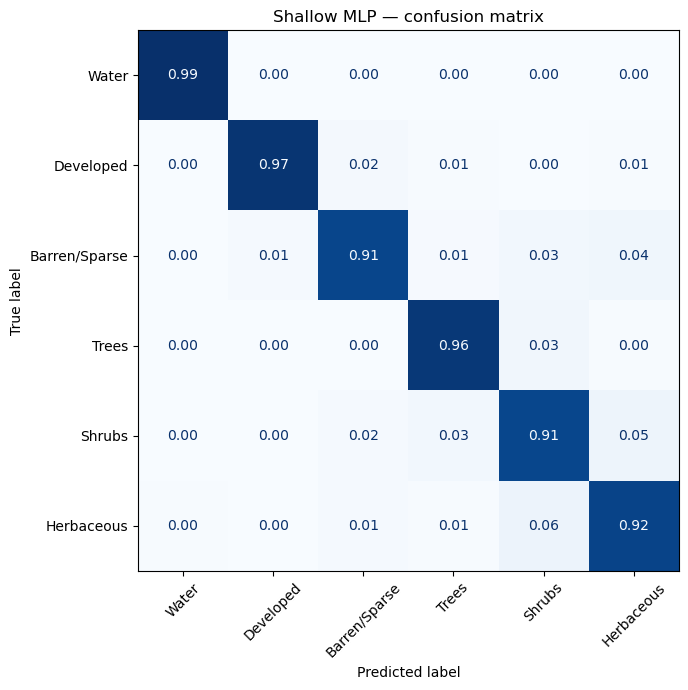

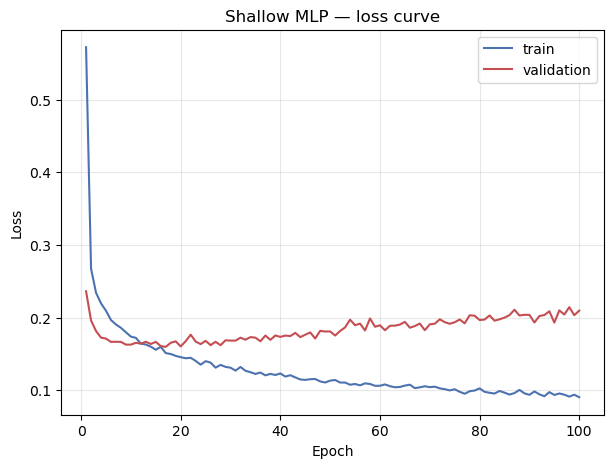

In [14]:
# ── Shallow MLP ─────────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'MLP')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_mlp(x_train, y_train, groups=groups_train, verbose=True, epochs=100), refit_models)

# ── Evaluate (no feature importances for an MLP) ────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
mlp_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='Shallow MLP — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch) ────────────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP — loss curve',
    save_path=paths['losscurve'])
#Overfitting observed with validation loss increasing as more epochs are run

### Shallow MLP (early stopping)

The same MLP trained with a high epoch cap and early stopping: training halts once validation loss stops improving and the best-epoch weights are restored, to curb overfitting.

Training time: 22.46 seconds
Early stopping restored best epoch 17
               precision    recall  f1-score   support

        Water      0.968     0.994     0.981       841
    Developed      0.948     0.975     0.961      1153
Barren/Sparse      0.851     0.899     0.874       882
        Trees      0.984     0.949     0.966      5054
       Shrubs      0.694     0.901     0.784      1576
   Herbaceous      0.975     0.916     0.945      6523

     accuracy                          0.932     16029
    macro avg      0.903     0.939     0.919     16029
 weighted avg      0.941     0.932     0.935     16029

Overall accuracy : 0.932
Balanced accuracy: 0.939
Macro F1         : 0.919
Cohen's kappa    : 0.907
MCC              : 0.908


<Axes: title={'center': 'Shallow MLP (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

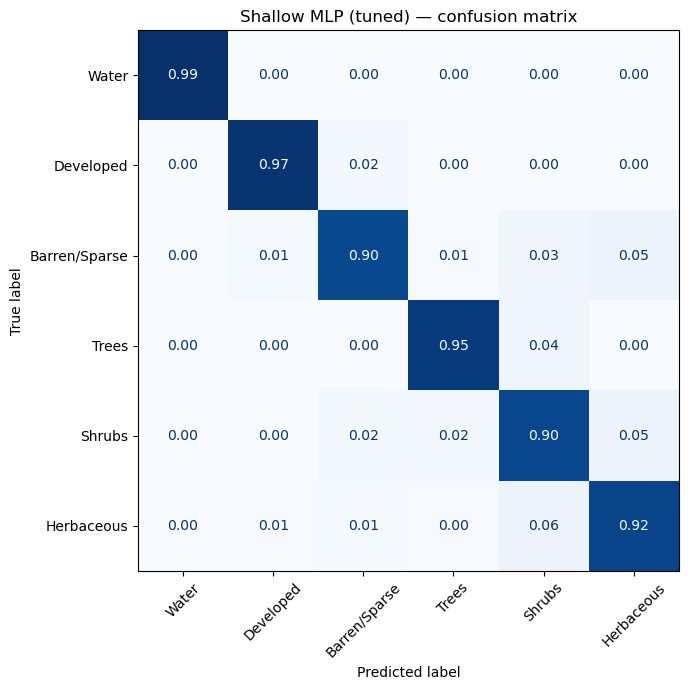

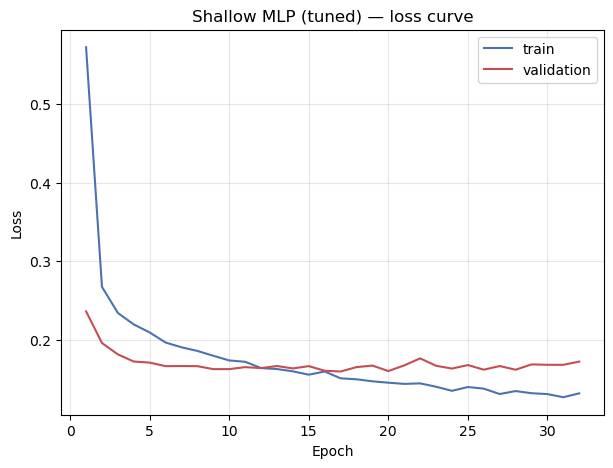

In [15]:
# ── Shallow MLP (early stopping) ────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'MLP', '_tuned')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_mlp(x_train, y_train, groups=groups_train,
                    early_stopping_rounds=15, epochs=300, verbose=True), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
mlp_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class_map_c1,
    title='Shallow MLP (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP (tuned) — loss curve',
    save_path=paths['losscurve'])

### CNN (embedding patches)

A small convolutional network that sees the 5×5×64 neighborhood window around each point instead of a single pixel, so it can learn spatial texture and context. Trained for a fixed number of epochs.

Training time: 72.31 seconds
               precision    recall  f1-score   support

        Water      0.970     0.995     0.982       841
    Developed      0.962     0.955     0.958      1153
Barren/Sparse      0.865     0.912     0.887       882
        Trees      0.977     0.960     0.969      5054
       Shrubs      0.740     0.876     0.802      1576
   Herbaceous      0.969     0.930     0.949      6523

     accuracy                          0.938     16029
    macro avg      0.914     0.938     0.925     16029
 weighted avg      0.943     0.938     0.940     16029

Overall accuracy : 0.938
Balanced accuracy: 0.938
Macro F1         : 0.925
Cohen's kappa    : 0.915
MCC              : 0.915


<Axes: title={'center': 'CNN (patches) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

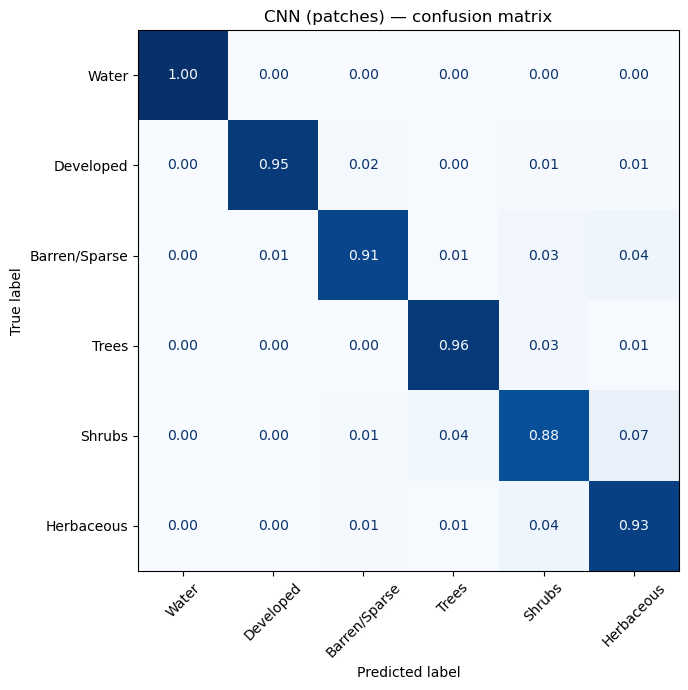

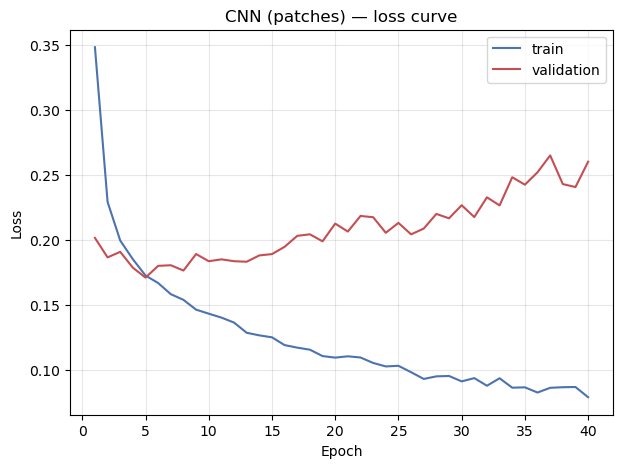

In [16]:
# ── CNN (embedding patches) ─────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'CNN')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_cnn(X_train_patch, y_train, groups=groups_train, verbose=True), refit_models)

# ── Evaluate (no feature importances for a CNN) ─────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
cnn_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class_map_c1,
    title='CNN (patches) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch) ────────────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (patches) — loss curve',
    save_path=paths['losscurve'])
#Significant overfitting observed with validation loss increasing as more epochs are run

### CNN (early stopping)

The same CNN with a high epoch cap and early stopping — training halts when validation loss plateaus and the best-epoch weights are restored.

Training time: 34.18 seconds
Early stopping restored best epoch 5
               precision    recall  f1-score   support

        Water      0.975     0.994     0.985       841
    Developed      0.945     0.963     0.954      1153
Barren/Sparse      0.824     0.923     0.871       882
        Trees      0.977     0.959     0.968      5054
       Shrubs      0.703     0.888     0.785      1576
   Herbaceous      0.976     0.907     0.940      6523

     accuracy                          0.931     16029
    macro avg      0.900     0.939     0.917     16029
 weighted avg      0.939     0.931     0.933     16029

Overall accuracy : 0.931
Balanced accuracy: 0.939
Macro F1         : 0.917
Cohen's kappa    : 0.905
MCC              : 0.906


<Axes: title={'center': 'CNN (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

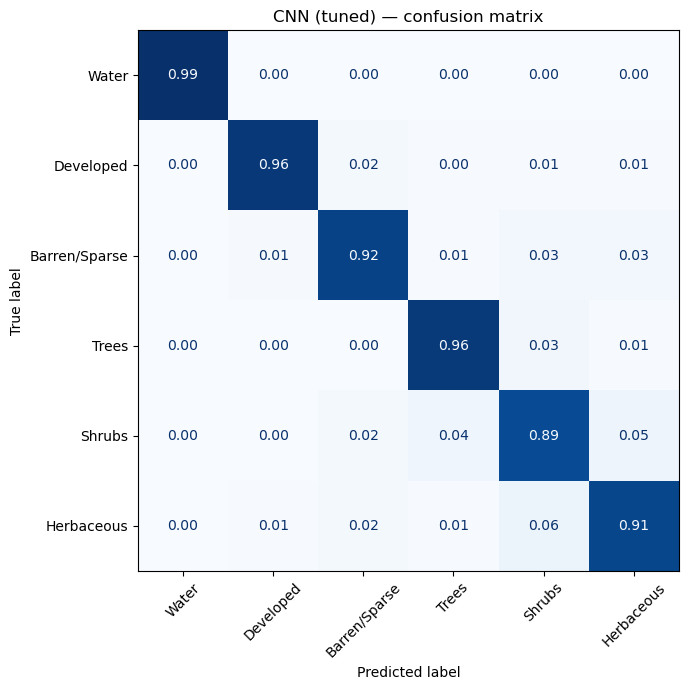

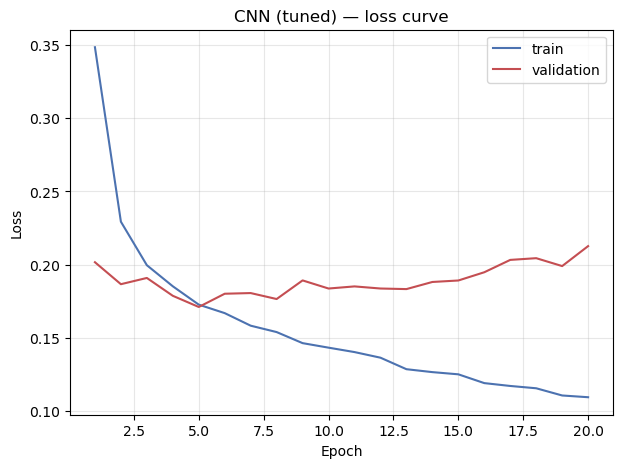

In [17]:
# ── CNN (early stopping) ────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c1, 'CNN', '_tuned')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_cnn(X_train_patch, y_train, groups=groups_train,
                    early_stopping_rounds=15, epochs=200, verbose=True), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
cnn_tuned_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class_map_c1,
    title='CNN (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (tuned) — loss curve',
    save_path=paths['losscurve'])

## Class Distribution

Level-1 class counts in the full modeling dataset (per-year observations) and within Washington / Oregon, to contextualize the model-comparison results that follow.

In [18]:
# ── Class Counts (full dataset vs Washington/Oregon) ────────────────────────────────────────
wa_or_states = get_wa_or_states()
state_of = assign_wa_or_state(expanded_Glance_Class1, wa_or_states)
class1_names = expanded_Glance_Class1['Glance_Class_ID_level1'].map(class1_dict)

class_counts = class_count_table(class1_names, class1_dict, state_of)
print('Level-1 class counts (per-year observations), % within each column:')
display(class_counts)

Level-1 class counts (per-year observations), % within each column:


,Full dataset,Washington,Oregon,WA + OR
Glance_Class_ID_level1,,,,
Water,"3,169 (5.0%)",46 (3.4%),13 (0.7%),59 (1.9%)
Ice/Snow,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Developed,"4,629 (7.2%)",89 (6.7%),95 (5.4%),184 (5.9%)
Barren/Sparse,"3,462 (5.4%)",62 (4.6%),178 (10.1%),240 (7.7%)
Trees,"20,049 (31.3%)",530 (39.6%),512 (28.9%),"1,042 (33.5%)"
Shrubs,"6,590 (10.3%)",90 (6.7%),320 (18.1%),410 (13.2%)
Herbaceous,"26,105 (40.8%)",521 (38.9%),651 (36.8%),"1,172 (37.7%)"
Total,"64,004 (100.0%)","1,338 (100.0%)","1,769 (100.0%)","3,107 (100.0%)"


## Model Comparison

Load every saved model and compare them on the shared test set, then on the Washington/Oregon subset. Every metric below except training time ranges 0–1 with higher being better:

- **Accuracy** — fraction of all test observations classified correctly. Simple, but dominated by the common classes when the data is imbalanced.
- **Balanced accuracy** — the average of per-class recall, so every class counts equally regardless of size; corrects accuracy's majority-class bias.
- **Subset balanced accuracy** — balanced accuracy computed over only Developed, Barren/Sparse, Trees, Shrubs, and Herbaceous (i.e. excluding Water and Ice/Snow), so the score reflects just the vegetation/land classes of interest. Classes with no test samples are dropped from the average.
- **Macro F1** — the unweighted mean of per-class F1 (the harmonic mean of precision and recall). The primary metric here, since it weights rare and common classes equally.
- **Weighted F1** — per-class F1 averaged by class frequency; reflects typical performance across the actual class mix.
- **Cohen's kappa** — agreement corrected for chance (0 = random, 1 = perfect); a chance-adjusted alternative to accuracy.
- **MCC** — Matthews correlation coefficient between predicted and true labels (−1 to 1); robust under imbalance and only high when the model does well across all classes.
- **Training time (s)** — wall-clock time to fit or search the model; lower is better.

A separate **per-class F1** table and heatmap break F1 down by individual land-cover class to show which classes each model handles well.

In both tables an **asterisk (`*`) marks the best model and a double asterisk (`**`) the second best**: in the summary table they flag the highest and next-highest value in each metric column (training time is marked with neither, since lower is better there), and in the per-class F1 table they flag the best and second-best model for each individual class. Ranking is by distinct value, so models tied for best all get `*` and `**` goes to the next distinct score down.

=== Summary metrics (saved to model_comparison_summary.csv) ===
* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).


,Accuracy,Balanced accuracy,Subset balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.9456,0.9394,0.9301,0.9346,0.9466,0.9243,0.9245,12.34
XGBoost,0.9471**,0.9379,0.9289,0.9354**,0.9479**,0.9262**,0.9263**,2.03
RF (tuned),0.9455,0.9385,0.9293,0.9343,0.9464,0.9241,0.9243,717.81
XGBoost (tuned),0.9501*,0.9420**,0.9330*,0.9386*,0.9507*,0.9304*,0.9305*,127.77
MLP,0.9369,0.9423*,0.9322**,0.9235,0.9389,0.9128,0.9137,73.09
MLP (tuned),0.9324,0.9390,0.9280,0.9185,0.9349,0.9067,0.9078,22.46
CNN,0.9384,0.9379,0.9265,0.9246,0.9399,0.9146,0.9150,72.31
CNN (tuned),0.9309,0.9389,0.9278,0.9170,0.9332,0.9047,0.9058,34.18
XGBoost (spatial),0.9468,0.9364,0.9267,0.9340,0.9474,0.9258,0.9259,525.56



=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===
* marks the best model for each class, ** the second best.


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,0.9881*,0.9851,0.9863**,0.9857,0.9795,0.9806,0.9824,0.9847,0.9851
Developed,0.9638,0.9658,0.9647,0.9721*,0.9667,0.9611,0.9582,0.9540,0.9678**
Barren/Sparse,0.9009,0.9059*,0.9028,0.9035**,0.8764,0.8743,0.8874,0.8706,0.8972
Trees,0.9699,0.9710**,0.9700,0.9723*,0.9695,0.9663,0.9686,0.9678,0.9707
Shrubs,0.8304**,0.8280,0.8275,0.8386*,0.8024,0.7843,0.8019,0.7846,0.8265
Herbaceous,0.9543,0.9566,0.9544,0.9592*,0.9464,0.9447,0.9494,0.9405,0.9569**


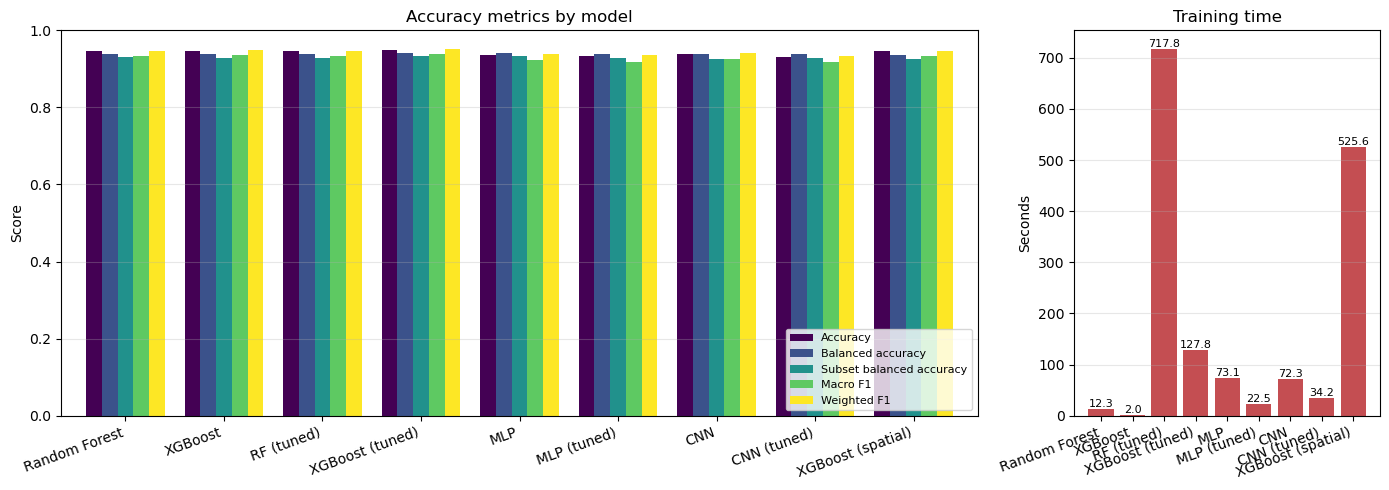

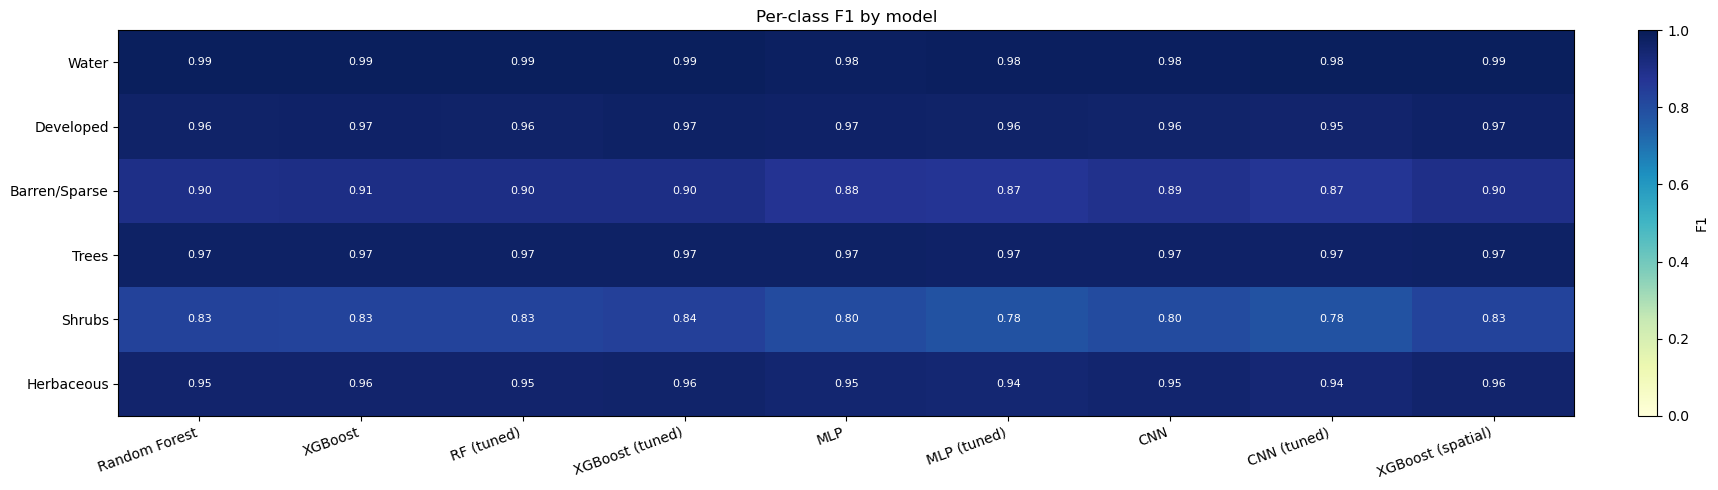

In [19]:
# ── Compare Models ──────────────────────────────────────────────────────────────────────────
# Load every saved model + its training time and compare on the shared held-out test set.
models = load_all_models(out_dir_c1, X_test_patch, x_test_nbhd)

# ── Compare and display ─────────────────────────────────────────────────────────────────────
summary_df, per_class_f1_df = compare_models(
    models, x_test, y_test, class_map=class_map_c1,
    save_dir=out_dir_c1, prefix='model_comparison', subset_classes=subset_c1)
print('=== Summary metrics (saved to model_comparison_summary.csv) ===')
print('* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).')
display(summary_df)
print('\n=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===')
print('* marks the best model for each class, ** the second best.')
display(per_class_f1_df)

WA/OR observations by split:
  Training: 2354 of 47975 (WA=1017, OR=1337)
  Test:     753 of 16029 (WA=321, OR=432)

Evaluating on 753 WA/OR test observations...

=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===
* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).


,Accuracy,Balanced accuracy,Subset balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.9363**,0.9376**,0.9251**,0.9348*,0.9372,0.9124,0.9128,12.34
XGBoost,0.9376*,0.9151,0.9216,0.9227,0.9383**,0.9140**,0.9143**,2.03
RF (tuned),0.9336,0.9387*,0.9265*,0.9328,0.9352,0.9091,0.9099,717.81
XGBoost (tuned),0.9376*,0.9340,0.9208,0.9334**,0.9388*,0.9142*,0.9146*,127.77
MLP,0.9203,0.9315,0.9178,0.9221,0.9238,0.8914,0.8932,73.09
MLP (tuned),0.9031,0.9261,0.9113,0.9023,0.9074,0.8688,0.8719,22.46
CNN,0.9349,0.9315,0.9178,0.9274,0.9363,0.9107,0.9112,72.31
CNN (tuned),0.9031,0.9245,0.9094,0.9020,0.9066,0.8689,0.8718,34.18
XGBoost (spatial),0.9323,0.9262,0.9232,0.9265,0.9337,0.9070,0.9073,525.56



=== WA/OR per-class F1 ===
* marks the best model for each class, ** the second best.


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,1.0000*,0.9375,1.0000*,1.0000*,1.0000*,0.9714**,1.0000*,1.0000*,0.9697
Developed,0.9293**,0.9091,0.9293**,0.9293**,0.9109,0.9126,0.9091,0.9109,0.9320*
Barren/Sparse,0.9457**,0.9375,0.9457**,0.9365,0.9683*,0.9242,0.9147,0.8794,0.9440
Trees,0.9819,0.9839**,0.9778,0.9819,0.9817,0.9734,0.9879*,0.9736,0.9818
Shrubs,0.8205**,0.8290*,0.8119,0.8122,0.7570,0.7364,0.8182,0.7512,0.8020
Herbaceous,0.9312,0.9391**,0.9324,0.9403*,0.9145,0.8956,0.9348,0.8969,0.9295


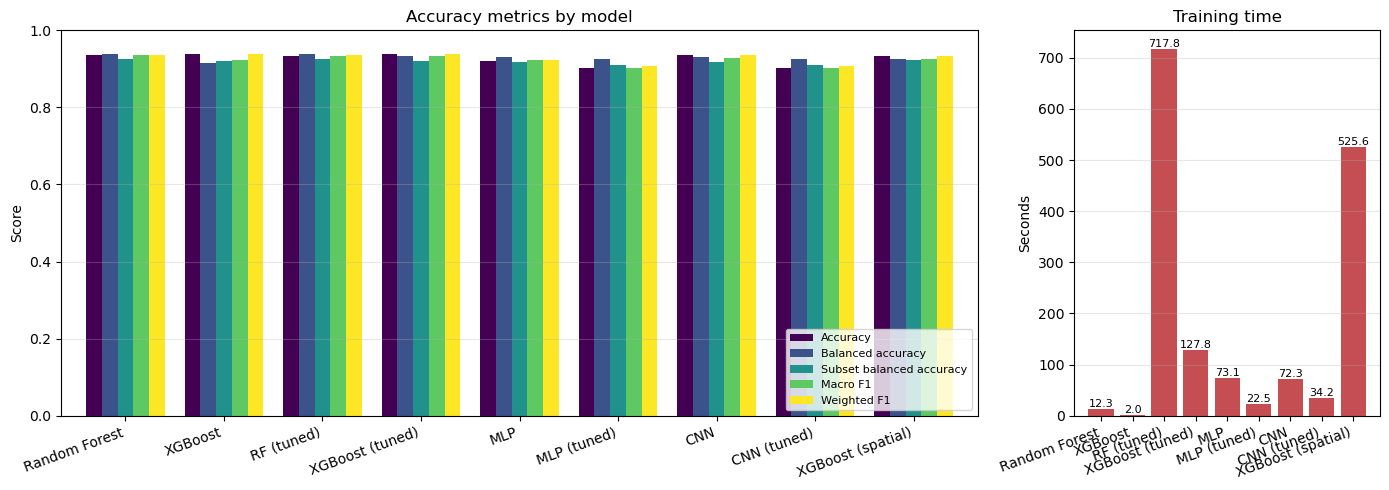

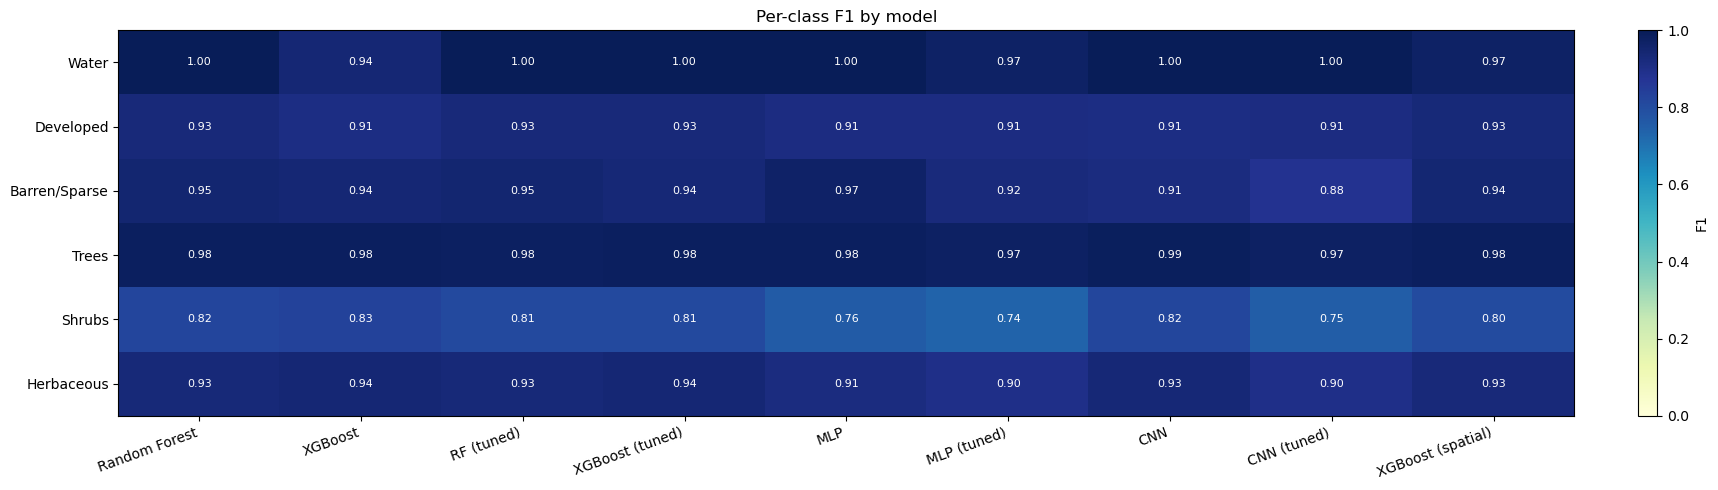

In [20]:
# ── Compare Models — Washington/Oregon subset ───────────────────────────────────────────────
# How many WA/OR observations are in train vs test, and how well do the models predict
# the WA/OR observations within the test set? Reuses wa_or_states/state_of from the
# Class Distribution cell above.
in_wa_or = state_of.notna()

# ── Counts in train vs test ─────────────────────────────────────────────────────────────────
train_state, test_state = state_of.loc[x_train.index], state_of.loc[x_test.index]
print('WA/OR observations by split:')
print(f"  Training: {int(in_wa_or.loc[x_train.index].sum())} of {len(x_train)} "
      f"(WA={int((train_state == 'Washington').sum())}, OR={int((train_state == 'Oregon').sum())})")
print(f"  Test:     {int(in_wa_or.loc[x_test.index].sum())} of {len(x_test)} "
      f"(WA={int((test_state == 'Washington').sum())}, OR={int((test_state == 'Oregon').sum())})")

# ── Restrict the test set to WA/OR (mask is in x_test / X_test_patch row order) ─────────────
mask = in_wa_or.loc[x_test.index].values
x_test_wa_or = x_test[mask]
y_test_wa_or = y_test[mask]
X_test_patch_wa_or = X_test_patch[mask]
x_test_nbhd_wa_or = x_test_nbhd[mask]

# ── Compare and display ─────────────────────────────────────────────────────────────────────
models_wa_or = load_all_models(out_dir_c1, X_test_patch_wa_or, x_test_nbhd_wa_or)
print(f'\nEvaluating on {int(mask.sum())} WA/OR test observations...')
summary_wa_or_df, per_class_wa_or_df = compare_models(
    models_wa_or, x_test_wa_or, y_test_wa_or, class_map=class_map_c1,
    save_dir=out_dir_c1, prefix='model_comparison_WA_OR', subset_classes=subset_c1)
print('\n=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===')
print('* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).')
display(summary_wa_or_df)
print('\n=== WA/OR per-class F1 ===')
print('* marks the best model for each class, ** the second best.')
display(per_class_wa_or_df)

# Conclusions - Class 1

Overall, the tuned XGBoost model performs best. It achieves the highest values for all evaluation metrics in the North America–wide dataset except balanced accuracy (slightly less than MLP) and the highest values for most metrics in the Pacific Northwest dataset. In the North America-wide dataset, the tuned Random Forest model has a slightly higher balanced accuracy and the untuned random forest has a slightly better macro F1. In the North America–wide dataset, the tuned XGBoost model also achieves the highest F1 scores for all land cover classes except water (best: Random Forest) and barren/sparse (best: untuned XGBoost). In the Pacific Northwest dataset, the XGBoost performs similarly to the best performing models for predicting each of the classes, but it not always the best performing model. As expected, all models perform better on the more common classes, such as trees, and less well on the rarer shrub class.

The tuned XGBoost model has similar values for overall accuracy, balanced accuracy, macro F1, and weighted F1, indicating that it performs consistently across classes. The slightly lower macro F1 score suggests that performance on the less common classes is somewhat weaker than on the more common classes. The confusion matrix shows that 2% of tree pixels and 3% of herbaceous pixels are incorrectly classified as shrubs. The largest sources of confusion are barren/sparse pixels being misclassified as herbaceous (6%) and shrub pixels being misclassified as either trees (5%) or herbaceous (6%).

# Level 2 (13-class) Classification

Repeats the full model suite above for GLanCE **Level 2** (13 classes: Water, Ice/Snow, Developed, Soil, Rock, Beach/Sand, Deciduous, Evergreen, Mixed, Shrub, Grassland, Agriculture, Moss/Lichen) — a finer, more imbalanced scheme than Level 1 (e.g. Grassland ~11.7k rows vs Moss/Lichen ~220). Every `fit_*`/`tune_*` function and `Evaluation.py` helper already accepts an arbitrary class map, so no modeling code changes here — only the training data, class map, and output directory (`Model_Outputs/Class2/`) switch. The cached AlphaEarth patches from the Level-1 section are reused (Level-2 rows are a subset of Level-1 rows, so no new Earth Engine sampling is needed).

## Data Preparation

Rebuild the train/test split, patch arrays, and neighborhood features for the Level-2 label column, and point `out_dir`/`class_map` at the Level-2 outputs.

In [21]:
# ── Level 2 data prep ───────────────────────────────────────────────────────────────────────
expanded_Glance_Class2_Clean = expanded_Glance_Class2.drop(columns=["geometry", "Year", "Lat", "Lon"])

x_train2, x_test2, y_train2, y_test2 = split_data(expanded_Glance_Class2_Clean, "Glance_Class_ID_level2")
groups_train2 = expanded_Glance_Class2_Clean.loc[x_train2.index, "Glance_ID"]

# ── Realign the cached patches to the Level-2 rows (subset of Level-1; no resampling) ───────
X_patch_all_c2 = align_patch_arrays(
    X_patch_all, expanded_Glance_Class1[['Glance_ID', 'Year']], expanded_Glance_Class2[['Glance_ID', 'Year']])
X_train_patch2 = X_patch_all_c2[x_train2.index.values]
X_test_patch2 = X_patch_all_c2[x_test2.index.values]

# ── Neighborhood mean/std features, derived from the realigned patches ──────────────────────
nbhd_features2 = neighborhood_stats(X_patch_all_c2)
nbhd_features2.index = expanded_Glance_Class2.index
x_train_nbhd2 = pd.concat([x_train2, nbhd_features2.loc[x_train2.index]], axis=1)
x_test_nbhd2 = pd.concat([x_test2, nbhd_features2.loc[x_test2.index]], axis=1)

# ── Route Level-2 outputs to their own subfolder ────────────────────────────────────────────
out_dir_c2 = os.path.join(MODEL_DIR, 'Class2')
class_map_c2 = class2_dict
subset_c2 = class2_subset
os.makedirs(out_dir_c2, exist_ok=True)

print(f'Level-2 rows: {len(expanded_Glance_Class2)}  train/test: {len(x_train2)}/{len(x_test2)}')

Level-2 rows: 48092  train/test: 36042/12050


## Models

Same 9 variants as the Level-1 section, fit (or loaded, when `refit_models=False`) on the Level-2 data and saved to `Model_Outputs/Class2/`. `RF (tuned)`, `XGBoost (tuned)`, and `XGBoost (spatial)` use `StratifiedGroupKFold(n_splits=4)`; if a Level-2 class has fewer than 4 distinct `Glance_ID` groups the search retries automatically with `n_splits=3`.

### Random Forest

Training time: 8.21 seconds
              precision    recall  f1-score   support

       Water      0.990     0.999     0.994       759
   Developed      0.963     0.964     0.963      1181
        Soil      0.719     0.601     0.655       213
        Rock      0.762     0.839     0.799       416
  Beach/Sand      0.824     0.568     0.672        74
   Deciduous      0.717     0.682     0.699       428
   Evergreen      0.794     0.874     0.832       892
       Mixed      0.589     0.434     0.500       281
       Shrub      0.740     0.902     0.813      1695
   Grassland      0.943     0.806     0.869      5384
 Agriculture      0.502     0.778     0.611       654
 Moss/Lichen      0.355     0.671     0.464        73

    accuracy                          0.833     12050
   macro avg      0.742     0.760     0.739     12050
weighted avg      0.854     0.833     0.837     12050

Overall accuracy : 0.833
Balanced accuracy: 0.760
Macro F1         : 0.739
Cohen's kappa    : 0.785
MCC  

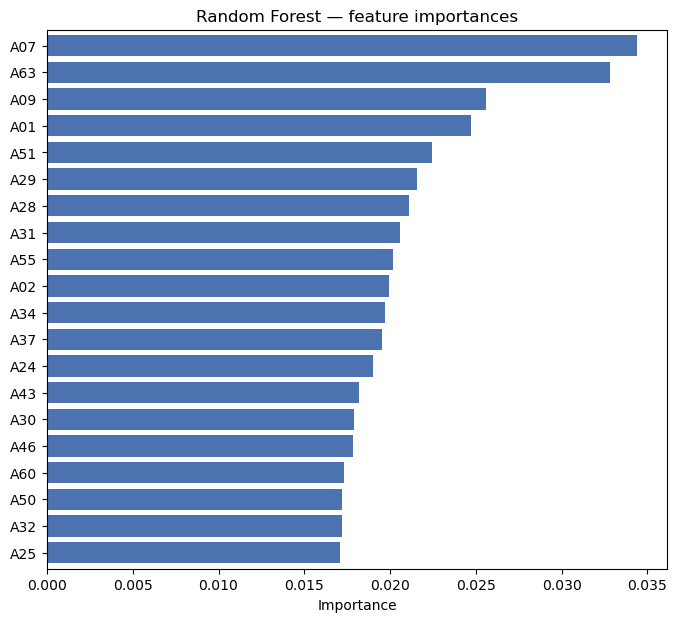

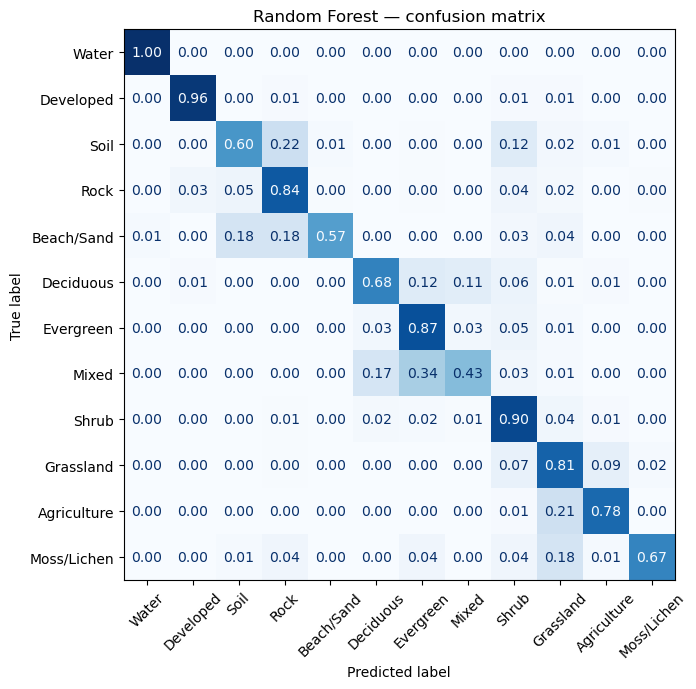

In [22]:
# ── Random Forest ───────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'random_forest')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'], lambda: fit_random_forest(x_train2, y_train2), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train2, title='Random Forest — feature importances',
    save_path=paths['importances'])
rf_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='Random Forest — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (RF has no epochs -> validation curve instead) ───────────────────
if refit_models:
    vc_param, vc_train, vc_val = rf_validation_curve(
        x_train2, y_train2, groups_train2, param_name='min_samples_leaf',
        param_range=(1, 2, 4, 8, 16))
    plot_validation_curve(
        vc_param, vc_train, vc_val, param_name='min_samples_leaf', scoring='macro F1',
        title='Random Forest — validation curve',
        save_path=paths['valcurve'])

### XGBoost

Training time: 3.53 seconds
              precision    recall  f1-score   support

       Water      0.995     0.996     0.995       759
   Developed      0.968     0.959     0.964      1181
        Soil      0.670     0.610     0.639       213
        Rock      0.790     0.825     0.807       416
  Beach/Sand      0.797     0.635     0.707        74
   Deciduous      0.731     0.647     0.686       428
   Evergreen      0.795     0.844     0.819       892
       Mixed      0.482     0.427     0.453       281
       Shrub      0.796     0.875     0.833      1695
   Grassland      0.914     0.872     0.893      5384
 Agriculture      0.585     0.705     0.639       654
 Moss/Lichen      0.268     0.260     0.264        73

    accuracy                          0.848     12050
   macro avg      0.733     0.721     0.725     12050
weighted avg      0.851     0.848     0.849     12050

Overall accuracy : 0.848
Balanced accuracy: 0.721
Macro F1         : 0.725
Cohen's kappa    : 0.800
MCC  

<Axes: title={'center': 'XGBoost — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

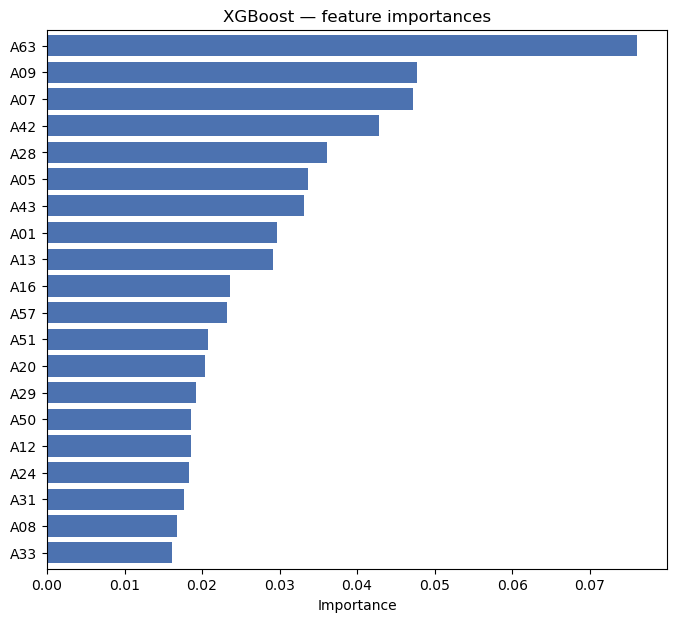

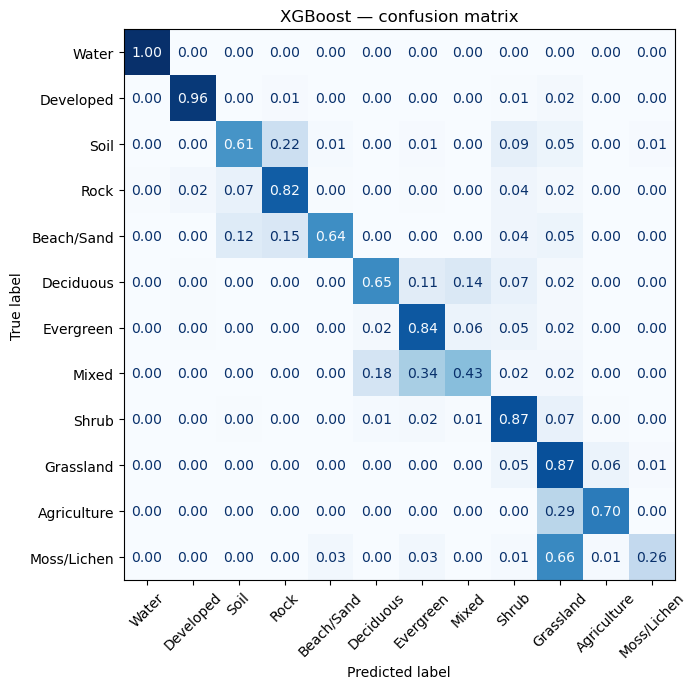

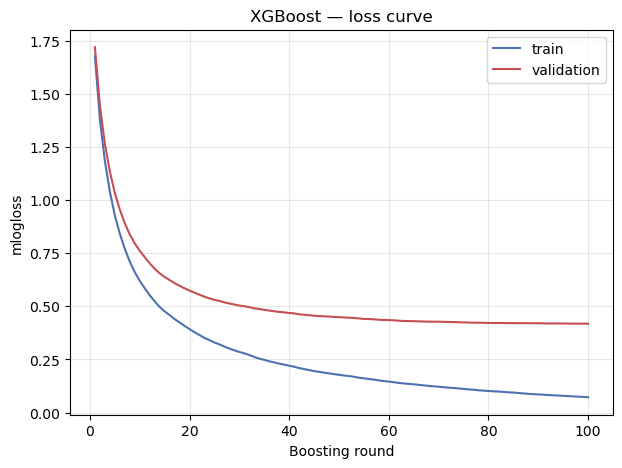

In [23]:
# ── XGBoost ─────────────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'XGBoost')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_xgboost(x_train2, y_train2, groups=groups_train2), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train2, title='XGBoost — feature importances',
    save_path=paths['importances'])
xgb_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='XGBoost — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ───────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost — loss curve',
    save_path=paths['losscurve'])

### Random Forest (tuned)

Search time: 497.50 seconds
              precision    recall  f1-score   support

       Water      0.990     0.999     0.994       759
   Developed      0.958     0.964     0.961      1181
        Soil      0.753     0.601     0.668       213
        Rock      0.755     0.844     0.797       416
  Beach/Sand      0.849     0.608     0.709        74
   Deciduous      0.729     0.680     0.704       428
   Evergreen      0.799     0.885     0.840       892
       Mixed      0.569     0.438     0.495       281
       Shrub      0.752     0.907     0.822      1695
   Grassland      0.947     0.800     0.867      5384
 Agriculture      0.499     0.795     0.613       654
 Moss/Lichen      0.328     0.795     0.464        73

    accuracy                          0.833     12050
   macro avg      0.744     0.776     0.745     12050
weighted avg      0.857     0.833     0.838     12050

Overall accuracy : 0.833
Balanced accuracy: 0.776
Macro F1         : 0.745
Cohen's kappa    : 0.786
MCC  

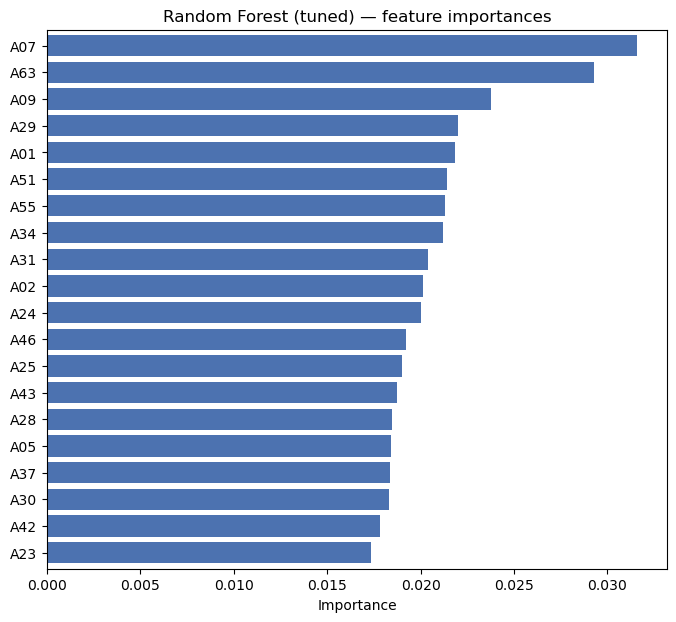

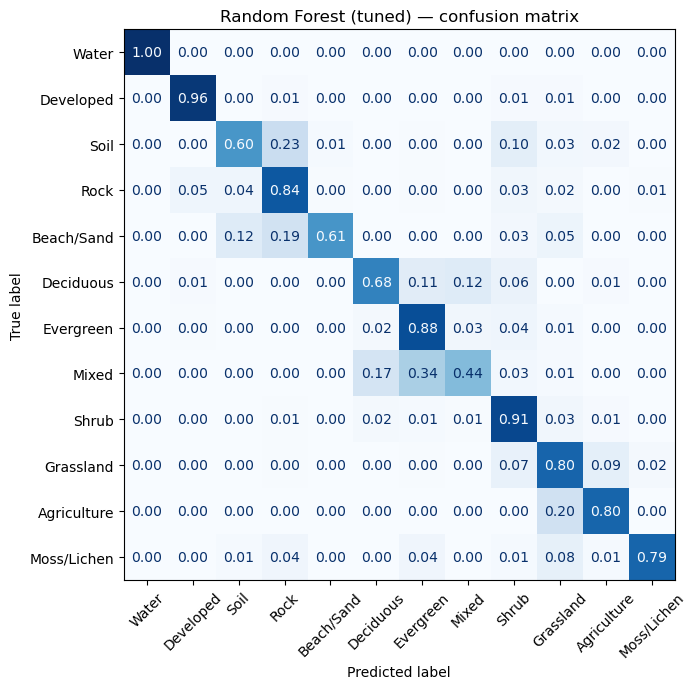

In [24]:
# ── Random Forest (grouped-CV tuned) ────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'random_forest_tuned', '_groupedCV')

def _fit_rf_tuned2():
    try:
        mdl, training_time_sec, best_params = tune_random_forest(x_train2, y_train2, groups_train2)
    except ValueError:
        print('StratifiedGroupKFold(n_splits=4) failed (a class has <4 groups) -- retrying with n_splits=3')
        mdl, training_time_sec, best_params = tune_random_forest(x_train2, y_train2, groups_train2, n_splits=3)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_rf_tuned2, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train2, title='Random Forest (tuned) — feature importances',
    save_path=paths['importances'])
rf_tuned_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='Random Forest (tuned) — confusion matrix',
    save_path=paths['confusion'])

### XGBoost (tuned)

Search time: 179.33 seconds
Early stopping chose best_iteration=263 (of up to 2000 rounds)
              precision    recall  f1-score   support

       Water      0.996     0.999     0.997       759
   Developed      0.968     0.959     0.964      1181
        Soil      0.660     0.592     0.624       213
        Rock      0.778     0.827     0.802       416
  Beach/Sand      0.738     0.608     0.667        74
   Deciduous      0.736     0.652     0.691       428
   Evergreen      0.803     0.862     0.831       892
       Mixed      0.531     0.456     0.490       281
       Shrub      0.804     0.871     0.836      1695
   Grassland      0.916     0.886     0.901      5384
 Agriculture      0.636     0.690     0.662       654
 Moss/Lichen      0.322     0.397     0.356        73

    accuracy                          0.856     12050
   macro avg      0.741     0.733     0.735     12050
weighted avg      0.857     0.856     0.856     12050

Overall accuracy : 0.856
Balanced accuracy

<Axes: title={'center': 'XGBoost (tuned) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

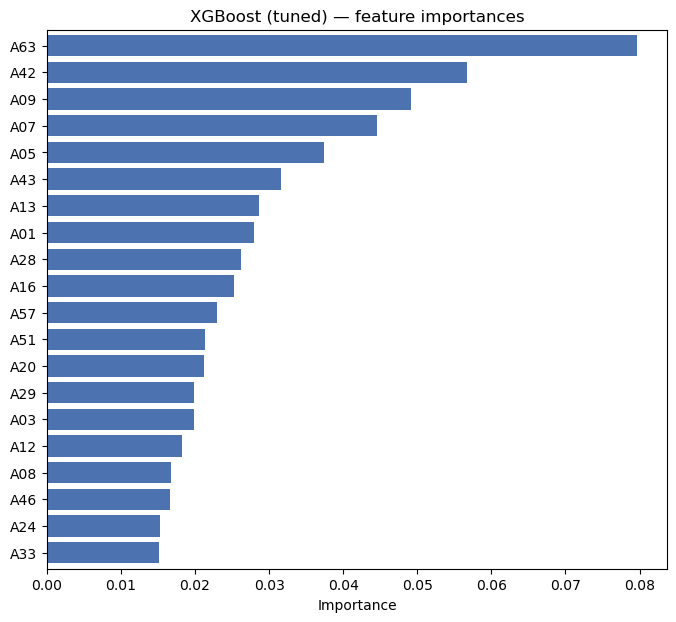

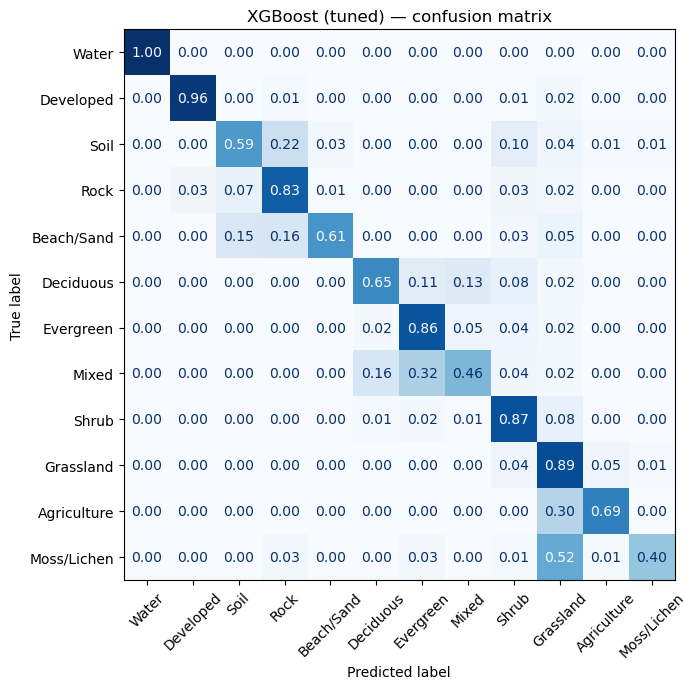

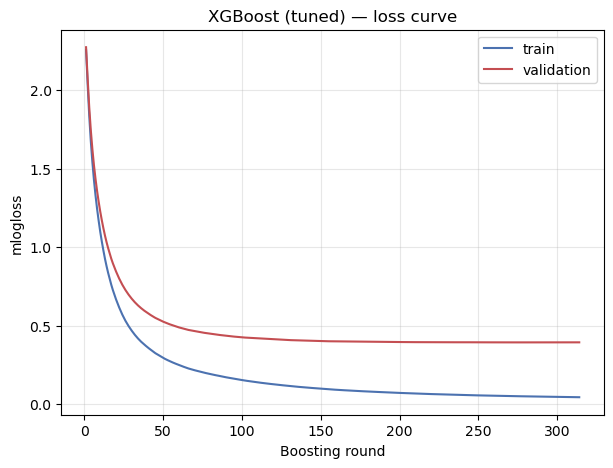

In [25]:
# ── XGBoost (grouped-CV tuned) ──────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'XGBoost_tuned', '_groupedCV')

def _fit_xgb_tuned2():
    try:
        mdl, training_time_sec, best_params = tune_xgboost(x_train2, y_train2, groups_train2)
    except ValueError:
        print('StratifiedGroupKFold(n_splits=4) failed (a class has <4 groups) -- retrying with n_splits=3')
        mdl, training_time_sec, best_params = tune_xgboost(x_train2, y_train2, groups_train2, n_splits=3)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_xgb_tuned2, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train2, title='XGBoost (tuned) — feature importances',
    save_path=paths['importances'])
xgb_tuned_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='XGBoost (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss; early stopping trims rounds) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (tuned) — loss curve',
    save_path=paths['losscurve'])

### XGBoost (spatial)

Search time: 686.48 seconds
Early stopping chose best_iteration=446 (of up to 2000 rounds)
              precision    recall  f1-score   support

       Water      0.995     0.996     0.995       759
   Developed      0.963     0.970     0.966      1181
        Soil      0.674     0.554     0.608       213
        Rock      0.782     0.844     0.812       416
  Beach/Sand      0.778     0.662     0.715        74
   Deciduous      0.750     0.659     0.701       428
   Evergreen      0.801     0.871     0.835       892
       Mixed      0.554     0.441     0.491       281
       Shrub      0.788     0.876     0.830      1695
   Grassland      0.914     0.883     0.898      5384
 Agriculture      0.628     0.657     0.642       654
 Moss/Lichen      0.312     0.329     0.320        73

    accuracy                          0.854     12050
   macro avg      0.745     0.728     0.735     12050
weighted avg      0.855     0.854     0.854     12050

Overall accuracy : 0.854
Balanced accuracy

<Axes: title={'center': 'XGBoost (spatial) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

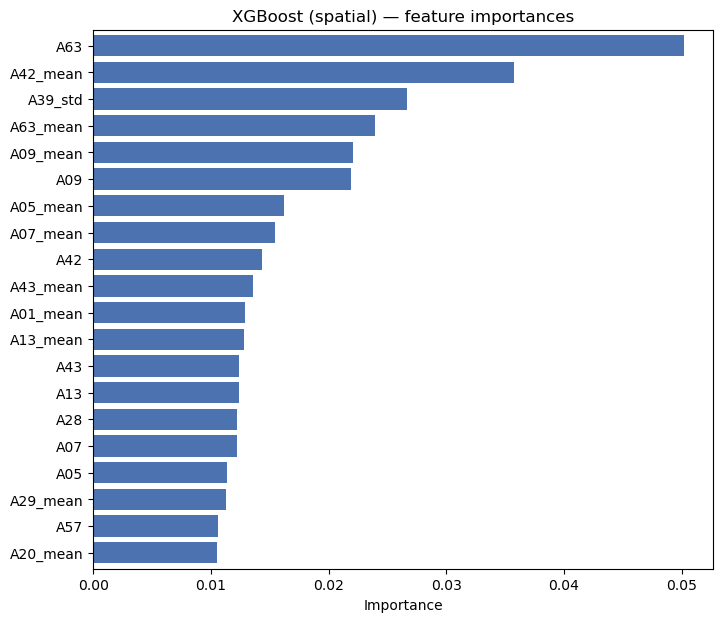

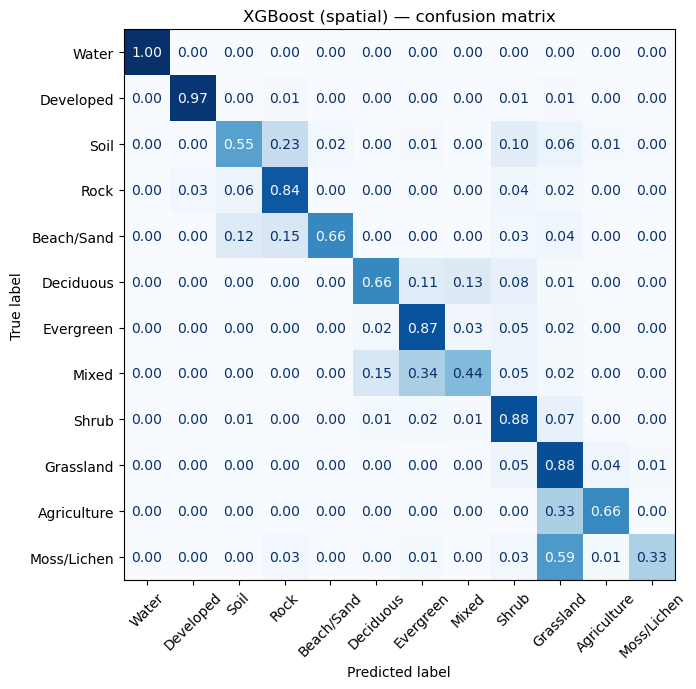

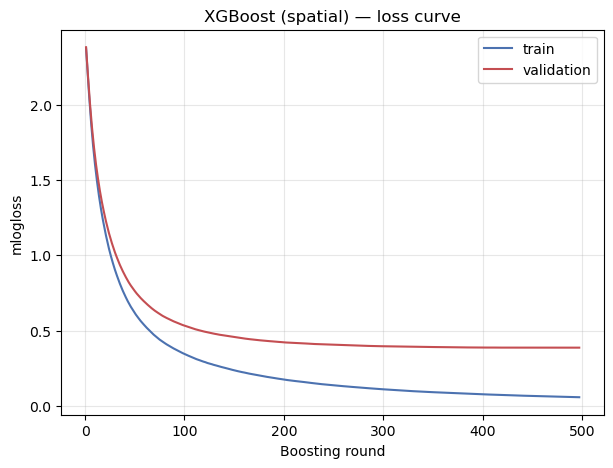

In [26]:
# ── XGBoost (spatial) ───────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'XGBoost_nbhd_tuned', '_spatial')

def _fit_xgb_spatial2():
    try:
        mdl, training_time_sec, best_params = tune_xgboost(x_train_nbhd2, y_train2, groups_train2)
    except ValueError:
        print('StratifiedGroupKFold(n_splits=4) failed (a class has <4 groups) -- retrying with n_splits=3')
        mdl, training_time_sec, best_params = tune_xgboost(x_train_nbhd2, y_train2, groups_train2, n_splits=3)
    print(f'Best params: {best_params}')
    return mdl, training_time_sec, best_params

mdl, training_time_sec = fit_or_load(paths['model'], paths['time'], _fit_xgb_spatial2, refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train_nbhd2, title='XGBoost (spatial) — feature importances',
    save_path=paths['importances'])
xgb_nbhd_tuned_metrics2 = evaluate_model(
    mdl, x_test_nbhd2, y_test2, class_map=class_map_c2,
    title='XGBoost (spatial) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ───────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (spatial) — loss curve',
    save_path=paths['losscurve'])

### Shallow MLP

Training time: 56.93 seconds
              precision    recall  f1-score   support

       Water      0.991     0.996     0.993       759
   Developed      0.945     0.965     0.955      1181
        Soil      0.586     0.723     0.647       213
        Rock      0.761     0.827     0.793       416
  Beach/Sand      0.800     0.649     0.716        74
   Deciduous      0.663     0.661     0.662       428
   Evergreen      0.822     0.781     0.801       892
       Mixed      0.395     0.548     0.459       281
       Shrub      0.752     0.876     0.809      1695
   Grassland      0.969     0.637     0.768      5384
 Agriculture      0.330     0.927     0.487       654
 Moss/Lichen      0.223     0.904     0.358        73

    accuracy                          0.760     12050
   macro avg      0.686     0.791     0.704     12050
weighted avg      0.848     0.760     0.779     12050

Overall accuracy : 0.760
Balanced accuracy: 0.791
Macro F1         : 0.704
Cohen's kappa    : 0.706
MCC 

<Axes: title={'center': 'Shallow MLP — loss curve'}, xlabel='Epoch', ylabel='Loss'>

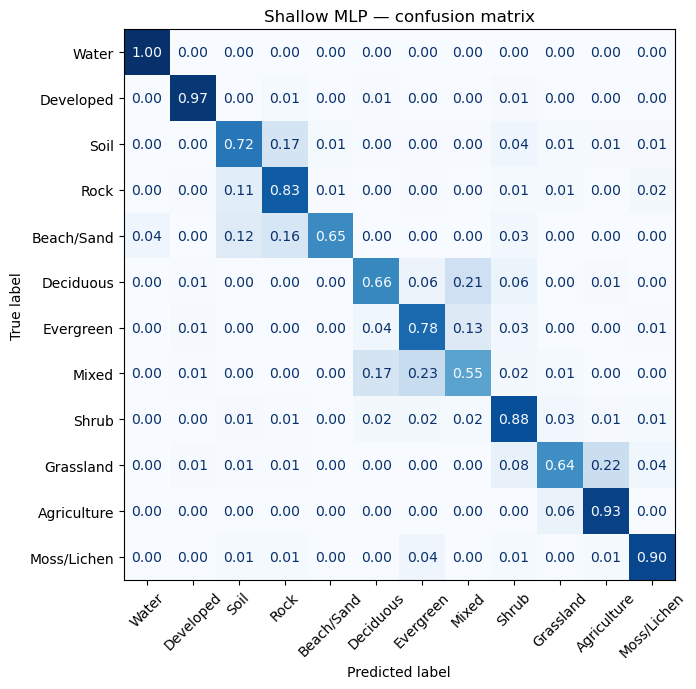

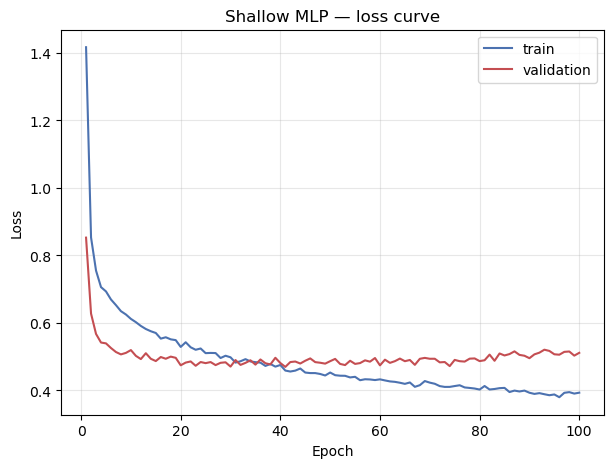

In [27]:
# ── Shallow MLP ─────────────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'MLP')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_mlp(x_train2, y_train2, groups=groups_train2, verbose=True, epochs=100), refit_models)

# ── Evaluate (no feature importances for an MLP) ────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
mlp_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='Shallow MLP — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch) ────────────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP — loss curve',
    save_path=paths['losscurve'])

### Shallow MLP (early stopping)

Training time: 29.75 seconds
Early stopping restored best epoch 41
              precision    recall  f1-score   support

       Water      0.991     0.996     0.993       759
   Developed      0.949     0.967     0.958      1181
        Soil      0.532     0.667     0.592       213
        Rock      0.739     0.844     0.788       416
  Beach/Sand      0.704     0.676     0.690        74
   Deciduous      0.613     0.680     0.645       428
   Evergreen      0.838     0.766     0.800       892
       Mixed      0.381     0.502     0.433       281
       Shrub      0.756     0.844     0.798      1695
   Grassland      0.963     0.666     0.787      5384
 Agriculture      0.349     0.902     0.503       654
 Moss/Lichen      0.211     0.890     0.341        73

    accuracy                          0.766     12050
   macro avg      0.669     0.783     0.694     12050
weighted avg      0.844     0.766     0.784     12050

Overall accuracy : 0.766
Balanced accuracy: 0.783
Macro F1        

<Axes: title={'center': 'Shallow MLP (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

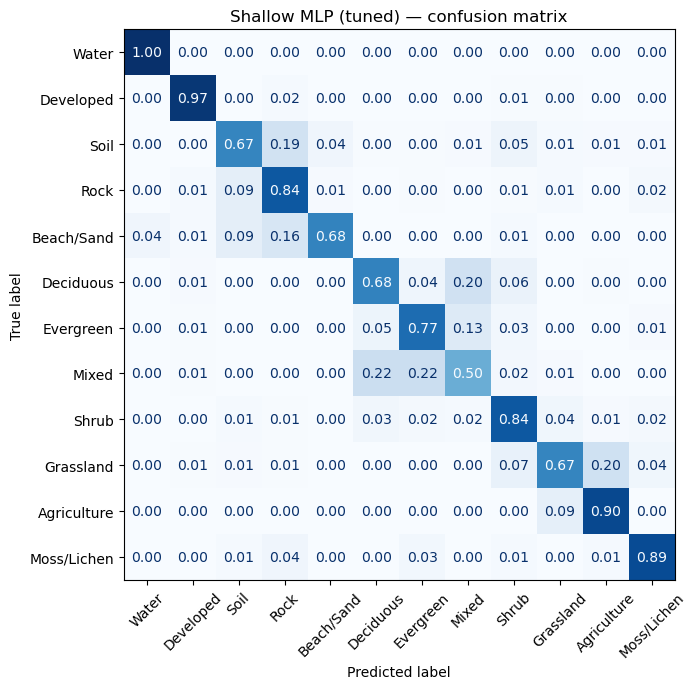

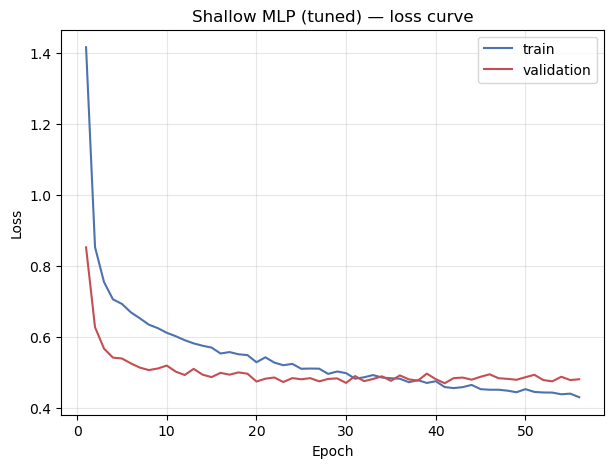

In [28]:
# ── Shallow MLP (early stopping) ────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'MLP', '_tuned')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_mlp(x_train2, y_train2, groups=groups_train2,
                    early_stopping_rounds=15, epochs=300, verbose=True), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
mlp_tuned_metrics2 = evaluate_model(
    mdl, x_test2, y_test2, class_map=class_map_c2,
    title='Shallow MLP (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP (tuned) — loss curve',
    save_path=paths['losscurve'])

### CNN (embedding patches)

Training time: 52.39 seconds
              precision    recall  f1-score   support

       Water      0.988     0.995     0.991       759
   Developed      0.946     0.959     0.952      1181
        Soil      0.552     0.718     0.624       213
        Rock      0.779     0.805     0.792       416
  Beach/Sand      0.769     0.676     0.719        74
   Deciduous      0.627     0.542     0.581       428
   Evergreen      0.798     0.809     0.804       892
       Mixed      0.379     0.569     0.455       281
       Shrub      0.780     0.842     0.810      1695
   Grassland      0.958     0.685     0.799      5384
 Agriculture      0.361     0.888     0.513       654
 Moss/Lichen      0.203     0.918     0.333        73

    accuracy                          0.772     12050
   macro avg      0.678     0.784     0.698     12050
weighted avg      0.845     0.772     0.790     12050

Overall accuracy : 0.772
Balanced accuracy: 0.784
Macro F1         : 0.698
Cohen's kappa    : 0.717
MCC 

<Axes: title={'center': 'CNN (patches) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

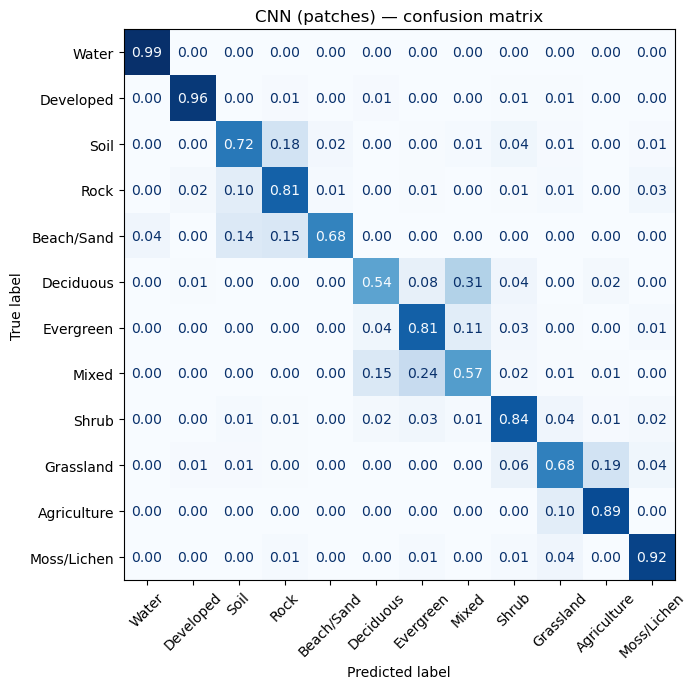

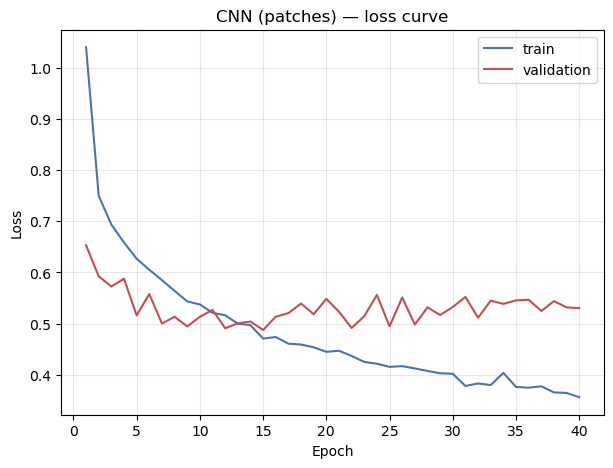

In [29]:
# ── CNN (embedding patches) ─────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'CNN')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_cnn(X_train_patch2, y_train2, groups=groups_train2, verbose=True), refit_models)

# ── Evaluate (no feature importances for a CNN) ─────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
cnn_metrics2 = evaluate_model(
    mdl, X_test_patch2, y_test2, class_map=class_map_c2,
    title='CNN (patches) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch) ────────────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (patches) — loss curve',
    save_path=paths['losscurve'])

### CNN (early stopping)

Training time: 38.64 seconds
Early stopping restored best epoch 15
              precision    recall  f1-score   support

       Water      0.992     0.996     0.994       759
   Developed      0.954     0.949     0.952      1181
        Soil      0.534     0.596     0.563       213
        Rock      0.752     0.810     0.780       416
  Beach/Sand      0.528     0.757     0.622        74
   Deciduous      0.611     0.675     0.642       428
   Evergreen      0.834     0.781     0.807       892
       Mixed      0.381     0.498     0.432       281
       Shrub      0.756     0.857     0.803      1695
   Grassland      0.963     0.618     0.753      5384
 Agriculture      0.311     0.934     0.466       654
 Moss/Lichen      0.217     0.890     0.349        73

    accuracy                          0.745     12050
   macro avg      0.653     0.780     0.680     12050
weighted avg      0.842     0.745     0.766     12050

Overall accuracy : 0.745
Balanced accuracy: 0.780
Macro F1        

<Axes: title={'center': 'CNN (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

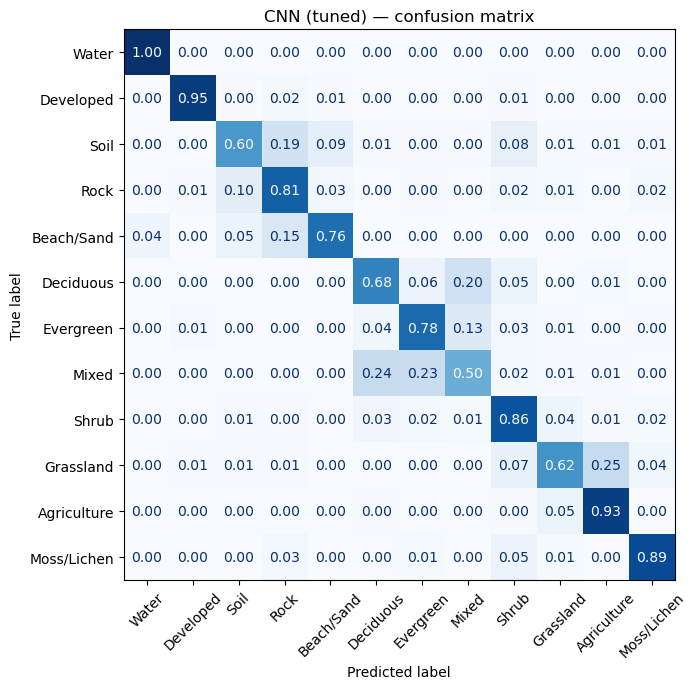

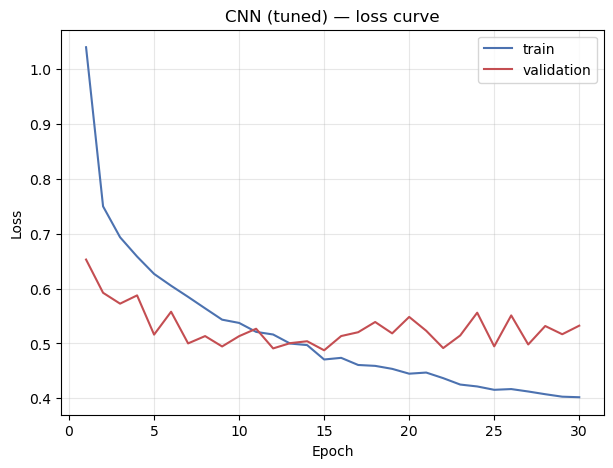

In [30]:
# ── CNN (early stopping) ────────────────────────────────────────────────────────────────────
paths = variant_paths(out_dir_c2, 'CNN', '_tuned')
mdl, training_time_sec = fit_or_load(
    paths['model'], paths['time'],
    lambda: fit_cnn(X_train_patch2, y_train2, groups=groups_train2,
                    early_stopping_rounds=15, epochs=200, verbose=True), refit_models)

# ── Evaluate ────────────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
cnn_tuned_metrics2 = evaluate_model(
    mdl, X_test_patch2, y_test2, class_map=class_map_c2,
    title='CNN (tuned) — confusion matrix',
    save_path=paths['confusion'])

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ─────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (tuned) — loss curve',
    save_path=paths['losscurve'])

## Class Distribution

Level-2 class counts in the full modeling dataset and within Washington/Oregon (reuses the WA/OR polygons fetched in the Level-1 Class Distribution cell above).

In [31]:
# ── Class Counts (full dataset vs Washington/Oregon) ────────────────────────────────────────
state_of2 = assign_wa_or_state(expanded_Glance_Class2, wa_or_states)
class2_names = expanded_Glance_Class2['Glance_Class_ID_level2'].map(class2_dict)

class_counts2 = class_count_table(class2_names, class2_dict, state_of2)
print('Level-2 class counts (per-year observations), % within each column:')
display(class_counts2)

Level-2 class counts (per-year observations), % within each column:


,Full dataset,Washington,Oregon,WA + OR
Glance_Class_ID_level2,,,,
Unknown,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Water,"3,169 (6.6%)",46 (5.4%),13 (1.0%),59 (2.8%)
Ice/Snow,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Developed,"4,629 (9.6%)",89 (10.4%),95 (7.5%),184 (8.6%)
Soil,950 (2.0%),30 (3.5%),58 (4.5%),88 (4.1%)
Rock,"1,648 (3.4%)",28 (3.3%),118 (9.3%),146 (6.8%)
Beach/Sand,351 (0.7%),0 (0.0%),0 (0.0%),0 (0.0%)
Deciduous,"1,595 (3.3%)",8 (0.9%),2 (0.2%),10 (0.5%)
Evergreen,"3,505 (7.3%)",71 (8.3%),42 (3.3%),113 (5.3%)


## Model Comparison

Same metrics and figures as the Level-1 comparison, computed for the Level-2 (13-class) models. **Subset balanced accuracy** here averages per-class recall over Developed, Soil, Deciduous, Evergreen, Mixed, Shrub, and Grassland only (classes with no test samples are dropped from the average).

In both tables an **asterisk (`*`) marks the best model and a double asterisk (`**`) the second best**: in the summary table they flag the highest and next-highest value in each metric column (training time is marked with neither, since lower is better there), and in the per-class F1 table they flag the best and second-best model for each individual class. Ranking is by distinct value, so models tied for best all get `*` and `**` goes to the next distinct score down.

=== Summary metrics (saved to model_comparison_class2_summary.csv) ===
* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).


,Accuracy,Balanced accuracy,Subset balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.8327,0.7598,0.7519,0.7393**,0.8369,0.7849,0.7883,8.21
XGBoost,0.8479,0.7213,0.7479,0.7250,0.8486,0.8003,0.8008,3.53
RF (tuned),0.8334,0.7761,0.7533**,0.7445*,0.8384,0.7865,0.7903,497.50
XGBoost (tuned),0.8555*,0.7332,0.7540*,0.7351,0.8557*,0.8098*,0.8100*,179.33
MLP,0.7601,0.7911*,0.7416,0.7041,0.7786,0.7055,0.7216,56.93
MLP (tuned),0.7656,0.7832,0.7272,0.6940,0.7839,0.7104,0.7235,29.75
CNN,0.7720,0.7839**,0.7321,0.6978,0.7900,0.7169,0.7283,52.39
CNN (tuned),0.7452,0.7803,0.7108,0.6803,0.7660,0.6885,0.7060,38.64
XGBoost (spatial),0.8543**,0.7285,0.7505,0.7345,0.8536**,0.8081**,0.8084**,686.48



=== Per-class F1 (saved to model_comparison_class2_per_class_f1.csv) ===
* marks the best model for each class, ** the second best.


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,0.9941,0.9954**,0.9941,0.9974*,0.9934,0.9934,0.9915,0.9941,0.9954**
Developed,0.9632,0.9638**,0.9607,0.9638**,0.9552,0.9581,0.9525,0.9516,0.9662*
Soil,0.6547**,0.6388,0.6684*,0.6238,0.6471,0.5917,0.6245,0.5632,0.6082
Rock,0.7986,0.8071**,0.7968,0.8019,0.7926,0.7879,0.7920,0.7801,0.8116*
Beach/Sand,0.6720,0.7068,0.7087,0.6667,0.7164**,0.6897,0.7194*,0.6222,0.7153
Deciduous,0.6994,0.6865,0.7037*,0.6914,0.6620,0.6445,0.5815,0.6415,0.7015**
Evergreen,0.8324,0.8189,0.8398*,0.8314,0.8011,0.8002,0.8036,0.8067,0.8346**
Mixed,0.5000*,0.4528,0.4950**,0.4904,0.4590,0.4332,0.4552,0.4321,0.4911
Shrub,0.8129,0.8334**,0.8224,0.8361*,0.8092,0.7975,0.8100,0.8034,0.8298
Grassland,0.8689,0.8927,0.8672,0.9005*,0.7684,0.7872,0.7987,0.7529,0.8983**


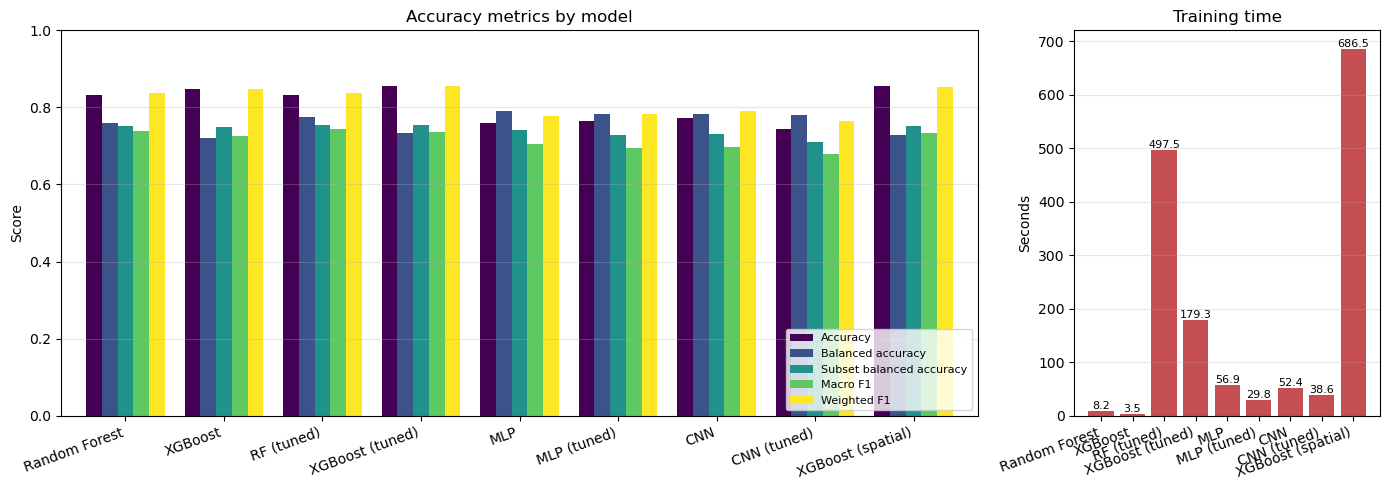

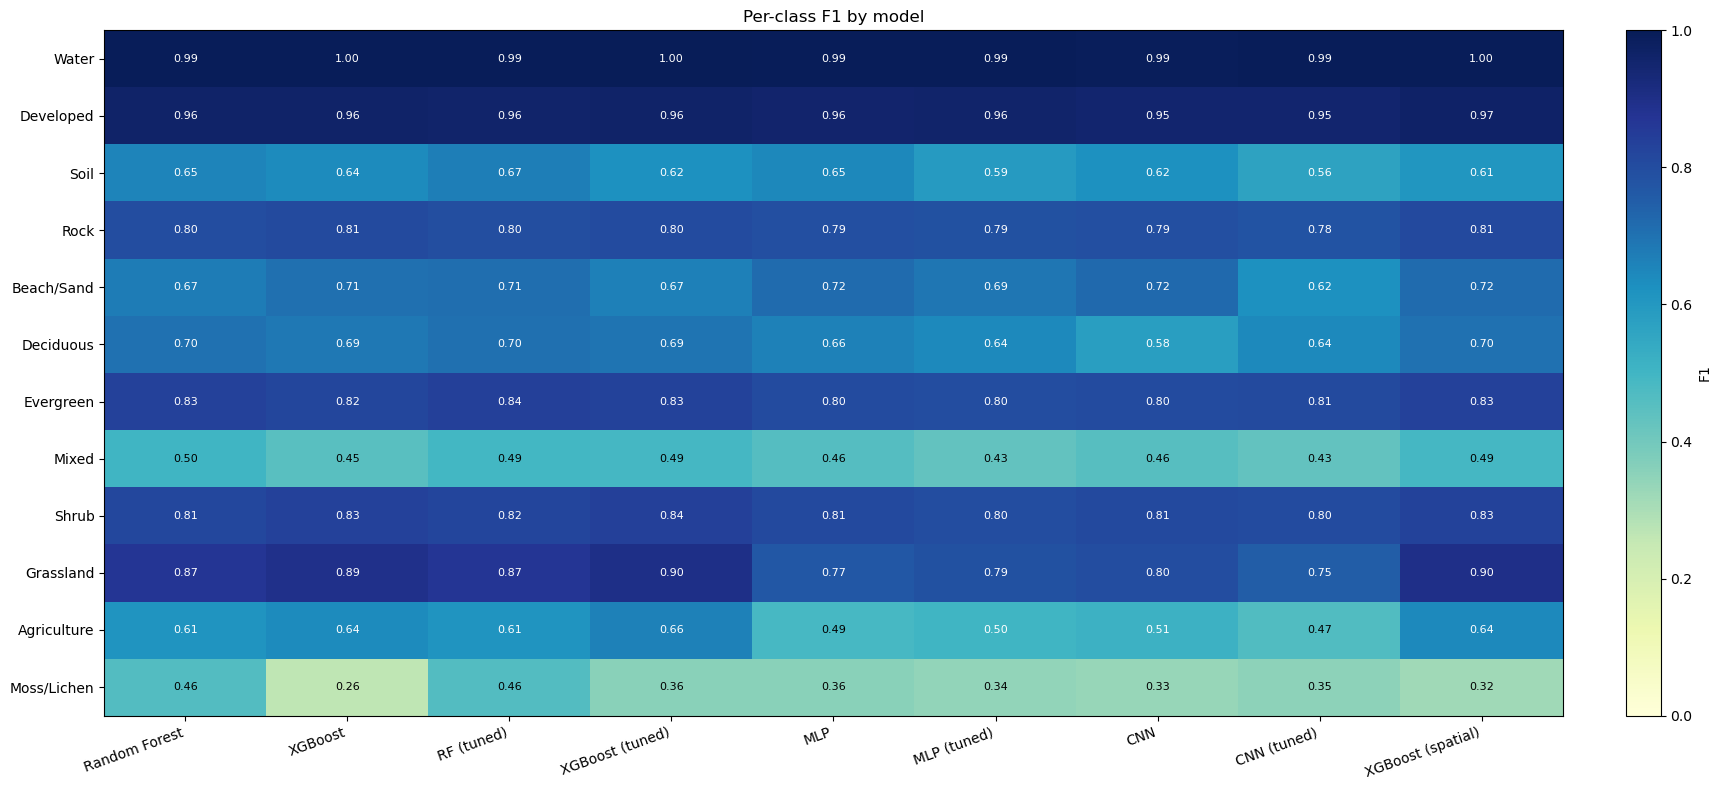

In [32]:
# ── Compare Models ──────────────────────────────────────────────────────────────────────────
models2 = load_all_models(out_dir_c2, X_test_patch2, x_test_nbhd2)

# ── Compare and display ─────────────────────────────────────────────────────────────────────
summary_df2, per_class_f1_df2 = compare_models(
    models2, x_test2, y_test2, class_map=class_map_c2,
    save_dir=out_dir_c2, prefix='model_comparison_class2', subset_classes=subset_c2)
print('=== Summary metrics (saved to model_comparison_class2_summary.csv) ===')
print('* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).')
display(summary_df2)
print('\n=== Per-class F1 (saved to model_comparison_class2_per_class_f1.csv) ===')
print('* marks the best model for each class, ** the second best.')
display(per_class_f1_df2)

WA/OR observations by split:
  Training: 1610 of 36042 (WA=646, OR=964)
  Test:     524 of 12050 (WA=213, OR=311)

Evaluating on 524 WA/OR test observations...
Subset balanced accuracy: no test samples for Deciduous -- averaging over the remaining 6 subset class(es).


/opt/anaconda3/envs/gee/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



=== WA/OR summary metrics (saved to model_comparison_class2_WA_OR_summary.csv) ===
* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).


,Accuracy,Balanced accuracy,Subset balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.8531,0.8954*,0.8973*,0.8580*,0.8656,0.7962,0.8038**,8.21
XGBoost,0.8397,0.7681,0.8000,0.7441,0.8490,0.7720,0.7738,3.53
RF (tuned),0.8416,0.8556,0.8543**,0.8359**,0.8582,0.7810,0.7894,497.50
XGBoost (tuned),0.8588**,0.7944,0.8229,0.7760,0.8657**,0.7987**,0.8003,179.33
MLP,0.7405,0.8704**,0.8348,0.7399,0.7720,0.6670,0.6996,56.93
MLP (tuned),0.7195,0.8636,0.8288,0.7409,0.7539,0.6422,0.6751,29.75
CNN,0.7634,0.8444,0.7917,0.7593,0.7891,0.6930,0.7216,52.39
CNN (tuned),0.7405,0.7927,0.7391,0.7129,0.7703,0.6629,0.6907,38.64
XGBoost (spatial),0.8645*,0.8258,0.8512,0.8064,0.8688*,0.8063*,0.8076*,686.48



=== WA/OR per-class F1 ===
* marks the best model for each class, ** the second best.


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,1.0000*,1.0000*,1.0000*,1.0000*,1.0000*,1.0000*,1.0000*,1.0000*,1.0000*
Developed,0.9524**,0.9524**,0.9412,0.9524**,0.9318,0.9412,0.9647*,0.9195,0.9302
Soil,0.8235**,0.6364,0.8485*,0.6667,0.6977,0.6250,0.7143,0.7273,0.7179
Rock,0.8101,0.7397,0.8462*,0.7123,0.8148,0.7805,0.8395**,0.7467,0.7467
Evergreen,0.9524*,0.8571,0.9375**,0.8923,0.7857,0.8136,0.8923,0.8438,0.8615
Mixed,1.0000*,0.4444,0.8571**,0.5714,0.5333,0.6667,0.5000,0.2857,0.7500
Shrub,0.8667,0.8832,0.8846**,0.8923*,0.8679,0.8447,0.8558,0.8517,0.8788
Grassland,0.8722,0.8859,0.8554,0.9056**,0.7366,0.7136,0.7506,0.7455,0.9077*
Agriculture,0.4444**,0.2979,0.3529,0.3913,0.2909,0.2832,0.3168,0.2963,0.4651*


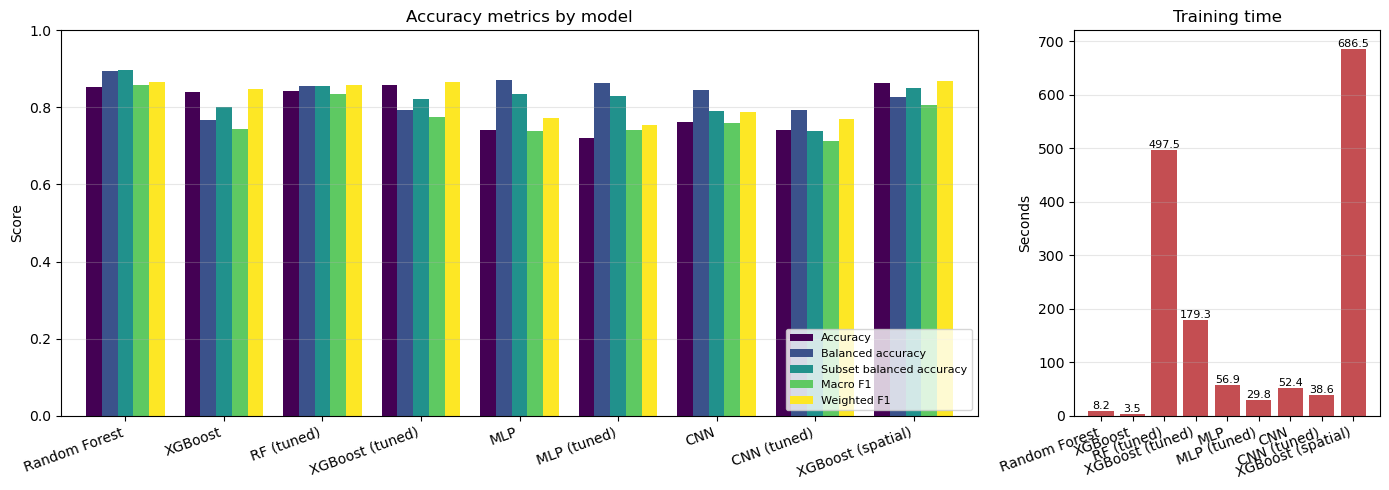

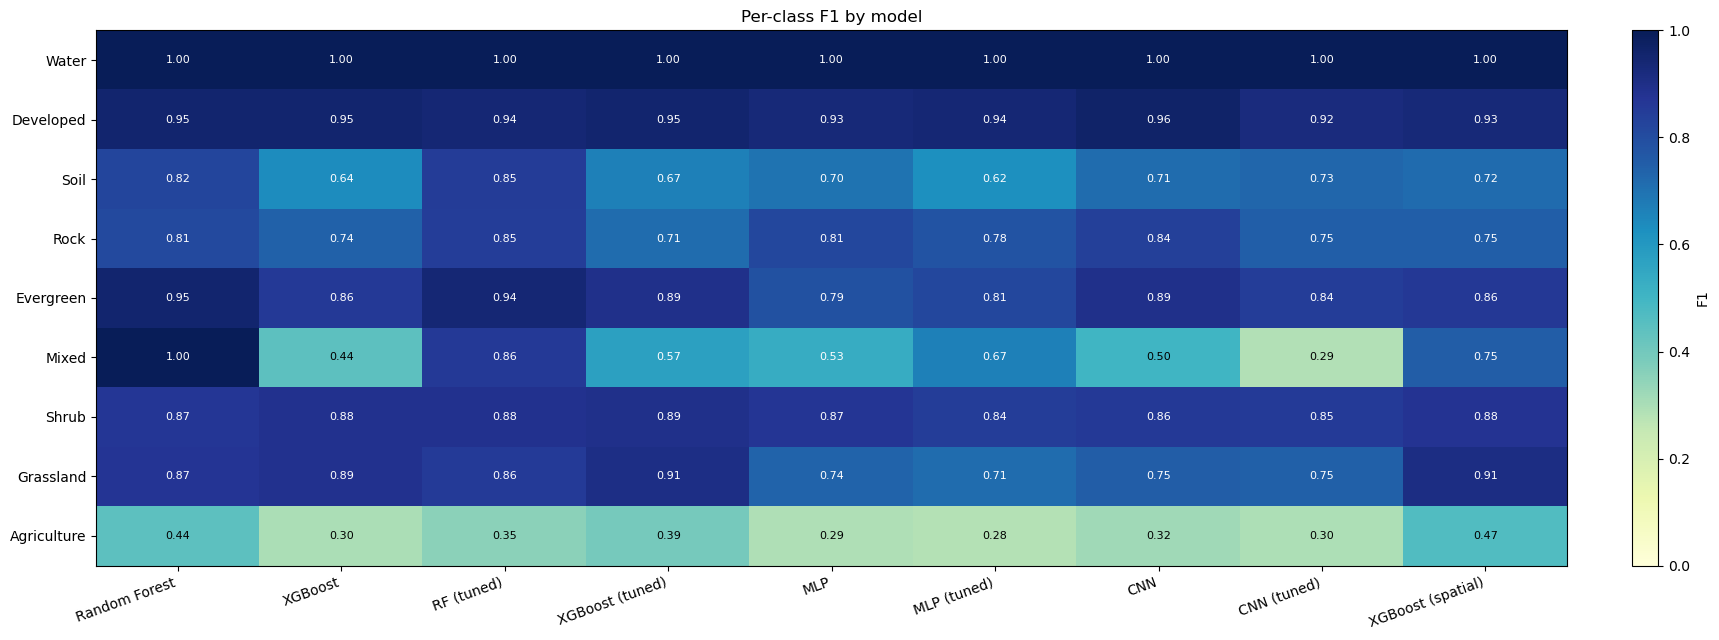

In [33]:
# ── Compare Models — Washington/Oregon subset ───────────────────────────────────────────────
in_wa_or2 = state_of2.notna()

# ── Counts in train vs test ─────────────────────────────────────────────────────────────────
train_state2, test_state2 = state_of2.loc[x_train2.index], state_of2.loc[x_test2.index]
print('WA/OR observations by split:')
print(f"  Training: {int(in_wa_or2.loc[x_train2.index].sum())} of {len(x_train2)} "
      f"(WA={int((train_state2 == 'Washington').sum())}, OR={int((train_state2 == 'Oregon').sum())})")
print(f"  Test:     {int(in_wa_or2.loc[x_test2.index].sum())} of {len(x_test2)} "
      f"(WA={int((test_state2 == 'Washington').sum())}, OR={int((test_state2 == 'Oregon').sum())})")

# ── Restrict the test set to WA/OR (mask is in x_test2 / X_test_patch2 row order) ───────────
mask2 = in_wa_or2.loc[x_test2.index].values
x_test2_wa_or = x_test2[mask2]
y_test2_wa_or = y_test2[mask2]
X_test_patch2_wa_or = X_test_patch2[mask2]
x_test_nbhd2_wa_or = x_test_nbhd2[mask2]

# ── Compare and display ─────────────────────────────────────────────────────────────────────
models2_wa_or = load_all_models(out_dir_c2, X_test_patch2_wa_or, x_test_nbhd2_wa_or)
print(f'\nEvaluating on {int(mask2.sum())} WA/OR test observations...')
summary_wa_or_df2, per_class_wa_or_df2 = compare_models(
    models2_wa_or, x_test2_wa_or, y_test2_wa_or, class_map=class_map_c2,
    save_dir=out_dir_c2, prefix='model_comparison_class2_WA_OR', subset_classes=subset_c2)
print('\n=== WA/OR summary metrics (saved to model_comparison_class2_WA_OR_summary.csv) ===')
print('* marks the best model for each metric, ** the second best (Training time has neither — lower is better, not higher).')
display(summary_wa_or_df2)
print('\n=== WA/OR per-class F1 ===')
print('* marks the best model for each class, ** the second best.')
display(per_class_wa_or_df2)

# Conclusions - Class 2

There is no single best model for the Level-2 classes. Model selection depends on what the model will be used for and which strengths and weaknesses matter most. Three models stand out: the tuned XGBoost, the spatial XGBoost, and the untuned Random Forest, with the tuned Random Forest a close fourth.

In the North America–wide dataset, the tuned XGBoost model is probably the best, achieving the highest overall accuracy, subset balanced accuracy, weighted F1, Cohen's kappa, and MCC. In the Pacific Northwest dataset, however, the spatial XGBoost model performs better, which indicates that spatial features likely matter more in this region. The untuned Random Forest model achieves the highest balanced accuracy and the highest subset balanced accuracy in the Pacific Northwest dataset, so it performs better when most of the classes matter equally.

These three models have similar confusion matrices, with each somewhat stronger on particular classes. Of the classes of interest here, soil is incorrectly identified as shrub 10–12% of the time, and agriculture is incorrectly identified as grassland 21–33% of the time. The untuned Random Forest model is the best of the three at avoiding the agriculture/grassland confusion (21%), followed by the tuned XGBoost model (30%) and the spatial XGBoost model (33%). As expected, the forest types (evergreen, mixed, and deciduous) are confused with one another.

As expected, all models predict the Level-2 classes less accurately than the Level-1 classes. Because of this, the class 1 labels will be predicted at the larger spatial coverage (i.e., the naturally forested land) across the Pacific Northwest. The tuned XGBoost model will be used. 